# Hong Kong Urban Heat
### What land surface temperature does and doesn't measure

**George Mills · 2026**

---

## Context

Satellite land surface temperature (LST) is the default evidence base for urban
heat studies. It is global, freely available and gives millions of observations
per city. This project works with roughly 1.7 million 30 m pixels across Hong
Kong. Weather stations, by contrast, give tens of readings.
That abundance is why LST dominates the literature. But **LST** measures the
radiating skin of the ground, while heat exposure, comfort and mortality all
track **air temperature**.

## Aim

**First, identify the patterns.** Map where Hong Kong is hot and quantify what
covaries with it — vegetation cover, elevation, surface brightness, distance to
the sea, administrative geography. This is the conventional urban heat analysis,
done properly and at full resolution.

**Second, test what those patterns actually mean.** Bring in ground-based air
temperature from 38 Hong Kong Observatory stations and ask whether the satellite
patterns describe the heat people experience, or something adjacent to it.

## Why Hong Kong

Few cities make a better test as roughly 40% of the territory is made up of
country parks, elevation runs from sea level to 955 m within about 25 km and
dense high-rise buildings sit directly against forested slopes. Land cover is
close to bimodal. That extreme contrast makes the failure modes of a
territory-wide correlation visible in a way a flatter, more uniform city would
not.

## What is compared

| | source | resolution | n |
|---|---|---|---|
| Land surface temperature | Landsat 8/9 C2 L2, 22 scenes | 30 m | ~1.7 M pixels |
| Vegetation / built-up | NDVI, NDBI from the same scenes | 30 m | ~1.7 M pixels |
| Surface albedo | Liang (2001) from the same scenes | 30 m | ~1.2 M pixels |
| Elevation | Copernicus GLO-30 DEM | 30 m | ~1.7 M pixels |
| **Air temperature** | **Hong Kong Observatory, 38 stations** | **point** | **13,784 station-days** |

Study period is May–October 2024, the warm season, with scene cloud cover below
30%.

## How to read this notebook

Each section gives at least one piece of evidence and states the finding as soon as they are found
(after the plot that supports it). Parts 2–4 build the conventional LST analysis conducted
and shows it breaking down. Part 5 introduces ground truth. Part 6 asks what
actually varies within the built up urban areas of the city.

---
# Part 1 · Setup

In [1]:
%pip install -q \
    numpy pandas matplotlib \
    geopandas shapely pyproj fiona rasterio \
    rioxarray xarray \
    pystac-client planetary-computer odc-stac \
    rasterstats folium \
    scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys, io, time, requests
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm

import geopandas as gpd
import rasterio, rioxarray, pyogrio
from pyproj import Transformer
from rasterio.features import rasterize
from affine import Affine
from scipy.stats import spearmanr
from scipy.ndimage import distance_transform_edt

import pystac_client, planetary_computer, odc.stac
from rasterstats import zonal_stats

PROJECT_DIR = Path.home() / "Documents" / "hong-kong-urban-heat"
DATA_RAW, DATA_PROCESSED = PROJECT_DIR / "data" / "raw", PROJECT_DIR / "data" / "processed"
FIGURES, RESULTS = PROJECT_DIR / "figures", PROJECT_DIR / "results"
for f in [DATA_RAW, DATA_PROCESSED, FIGURES, RESULTS]:
    f.mkdir(parents=True, exist_ok=True)

# Study design — single source of truth for every cell below
HK_BBOX    = [113.8, 22.15, 114.5, 22.6]   # lon_min, lat_min, lon_max, lat_max
CRS        = "EPSG:32650"                   # UTM 50N, metric
RESOLUTION = 30                             # Landsat native
DATE_RANGE = "2024-05-01/2024-10-31"        # warm season
MAX_CLOUD  = 30                             # scene-level, percent

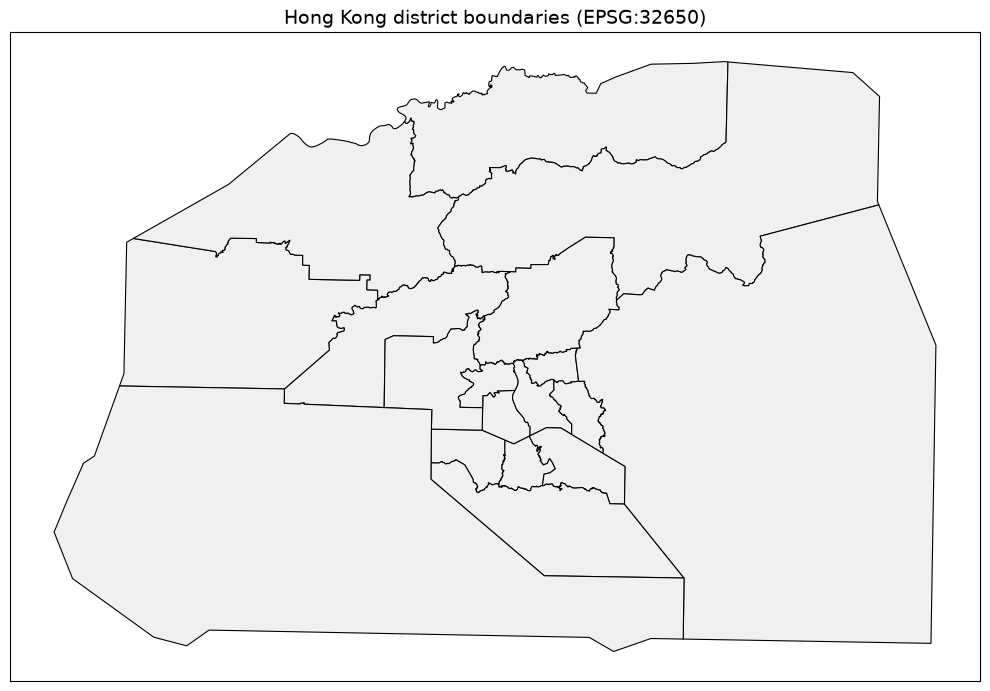

18 districts


In [3]:
# District boundaries — used for map context and zonal statistics throughout
districts = gpd.read_file("hksarboundaries.json")
bounds = districts.to_crs(CRS)          # reprojected once, reused everywhere

fig, ax = plt.subplots(figsize=(10, 9))
bounds.plot(ax=ax, facecolor="#f0f0f0", edgecolor="black", linewidth=0.8)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Hong Kong district boundaries (EPSG:32650)", fontsize=14)
plt.tight_layout(); plt.show()

print(len(districts),"districts")

---
# Part 2 · Building the surface temperature record

Landsat Collection 2 **Level-2** is the atmospherically corrected surface
product — Level-1 would confound atmospheric effects with genuine surface
properties.

Two choices were made that shape everything downstream:

**Median compositing rather than a single date.** One scene captures one
morning's weather. The per-pixel median across the season describes *typical*
summer surface conditions and is robust to residual cloud that survives QA
masking.

**Water excluded.** Sea surface temperature is not urban heat, and Hong Kong's
coastline would otherwise dominate the cool tail of every distribution.

In [4]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace)

search = catalog.search(
    collections=["landsat-c2-l2"], bbox=HK_BBOX, datetime=DATE_RANGE,
    query={"eo:cloud_cover": {"lt": MAX_CLOUD},
           "platform": {"in": ["landsat-8", "landsat-9"]}})

items = search.item_collection()
print(len(items), "scenes\n")
for it in sorted(items, key=lambda i: i.datetime):
    print(" ", it.datetime.date(), "", f"{it.properties['platform']:<10}",
          f"cloud {it.properties['eo:cloud_cover']:5.1f}%")

22 scenes

  2024-05-04  landsat-9  cloud  26.0%
  2024-05-12  landsat-8  cloud  20.7%
  2024-06-21  landsat-9  cloud   6.4%
  2024-06-29  landsat-8  cloud  11.5%
  2024-07-07  landsat-9  cloud   8.6%
  2024-07-23  landsat-9  cloud  29.1%
  2024-07-31  landsat-8  cloud  21.1%
  2024-08-07  landsat-8  cloud  12.9%
  2024-08-07  landsat-8  cloud  19.9%
  2024-08-24  landsat-9  cloud  25.2%
  2024-09-01  landsat-8  cloud   8.5%
  2024-09-01  landsat-8  cloud  21.7%
  2024-09-17  landsat-8  cloud  27.8%
  2024-09-24  landsat-8  cloud  11.9%
  2024-09-25  landsat-9  cloud  23.6%
  2024-10-02  landsat-9  cloud  12.1%
  2024-10-02  landsat-9  cloud  20.8%
  2024-10-03  landsat-8  cloud  26.4%
  2024-10-10  landsat-8  cloud   1.9%
  2024-10-10  landsat-8  cloud  23.4%
  2024-10-19  landsat-8  cloud   9.1%
  2024-10-19  landsat-8  cloud   8.2%


In [5]:
# Thermal band + QA. chunks={} makes this lazy — nothing downloads until .compute()
ds = odc.stac.load(items, bands=["lwir11", "qa_pixel"], crs=CRS,
                   resolution=RESOLUTION, bbox=HK_BBOX,
                   groupby="solar_day", chunks={})   # HK straddles two path/rows

# QA_PIXEL bits: 0 fill, 1 dilated cloud, 2 cirrus, 3 cloud, 4 shadow, 7 water
qa = ds.qa_pixel
bad = ((qa & (1 << 0)) | (qa & (1 << 1)) | (qa & (1 << 2))
       | (qa & (1 << 3)) | (qa & (1 << 4))) > 0
water = (qa & (1 << 7)) > 0     # kept separate: excluding sea is a choice, not a QA flag

#surface temperature scaling  goes from DN -> Kelvin -> Celsius
thermal = ds.lwir11.where(ds.lwir11 > 0)          # DN 0 is nodata
lst_c = (thermal * 0.00341802 + 149.0 - 273.15).where(~bad).where(~water)

lst_median = lst_c.median(dim="time").compute()   # the slow step
print("raw range:", f"{float(lst_median.min()):.1f}", "to",
      f"{float(lst_median.max()):.1f}", "°C")

# Physical clip removes cloud-edge pixels that pass QA but are obviously wrong
lst = lst_median.where((lst_median > 10) & (lst_median < 60))
vals = lst.values[np.isfinite(lst.values)]

print("valid pixels:", f"{vals.size:,}", f"({100 * vals.size / lst.size:.1f}% of grid)")
print("p2 / p50 / p98:", f"{np.percentile(vals, 2):.1f}", "/", f"{np.median(vals):.1f}",
      "/", f"{np.percentile(vals, 98):.1f}", "°C")

/opt/conda/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


raw range: -123.1 to 67.0 °C
valid pixels: 1,774,092 (42.6% of grid)
p2 / p50 / p98: 23.4 / 33.9 / 44.7 °C


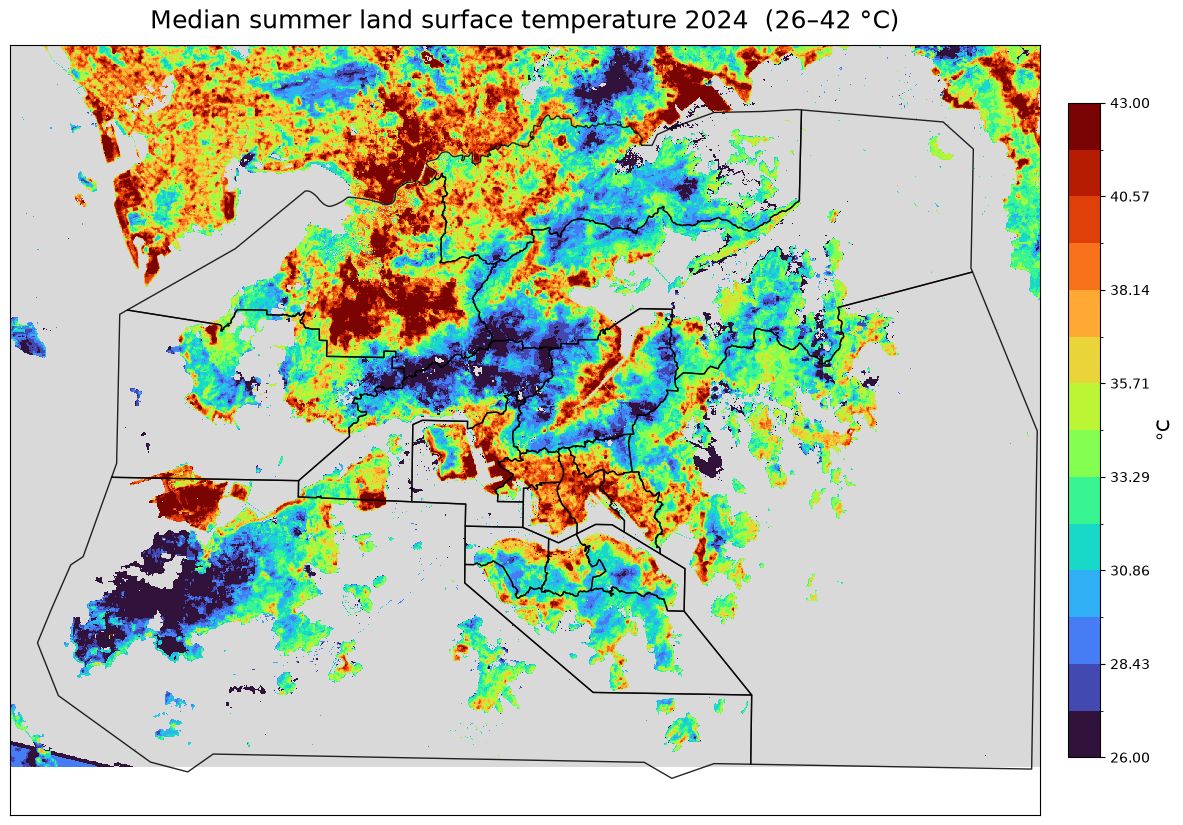

In [6]:
# Median summer surface temperature. Discrete colour bands rather than a
# continuous ramp, so values can be read straight off the bar.
vmin, vmax = np.percentile(vals, [5, 95])

abs_levels = np.linspace(np.floor(vmin), np.ceil(vmax), 15)

cmap_abs = plt.get_cmap("turbo", len(abs_levels) - 1).copy()
cmap_abs.set_bad("#d9d9d9")

extent = [float(lst.x.min()), float(lst.x.max()), float(lst.y.min()), float(lst.y.max())]

fig, ax = plt.subplots(figsize=(18, 10))
im = ax.imshow(lst.values, cmap=cmap_abs, norm=BoundaryNorm(abs_levels, cmap_abs.N),
               extent=extent, origin="upper", interpolation="nearest")
ax.set_title(f"Median summer land surface temperature 2024  ({vmin:.0f}–{vmax:.0f} °C)",
             fontsize=18, pad=12)
fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02,
             ticks=abs_levels[::2]).set_label("°C", fontsize=13)

bounds.boundary.plot(ax=ax, edgecolor="black", linewidth=1.0, alpha=0.85)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])

plt.savefig(FIGURES / "hk_lst_2024.png", dpi=200, bbox_inches="tight")
plt.show()


> ### The territory-wide pattern
>
> Around **1.77 million** valid pixels survive cloud, shadow and water masking.
> The urban core of Kowloon and northern Hong Kong Island reads clearly hot, the
> country parks clearly cool, and the anomaly panel sharpens the contrast against
> a territory median of roughly 33 °C.
>
> This is the surface urban heat island (SUHI) as conventionally mapped, and the
> picture almost every such study begins from. The rest of this notebook asks how
> much of it survives closer inspection.

In [7]:
# Zonal statistics by administrative district
lst_out = lst.rio.write_crs(CRS).fillna(-9999).rio.write_nodata(-9999)
tif_path = DATA_PROCESSED / "lst_median_2024.tif"
lst_out.rio.to_raster(tif_path)

stats = zonal_stats(bounds, str(tif_path),
                    stats=["mean", "median", "max", "count"], nodata=-9999)

results = bounds.copy()
for key in ["mean", "median", "max", "count"]:
    results[f"lst_{key}"] = [s[key] for s in stats]

results[["lst_mean", "lst_median", "lst_max"]] = results[["lst_mean", "lst_median", "lst_max"]].round(2)
results["lst_count"] = results["lst_count"].astype(int)
results = results.sort_values("lst_mean", ascending=False)

cols = [c for c in results.columns if c.startswith("lst_")]
name_col = next((c for c in results.columns
                 if "name" in c.lower() or "district" in c.lower()), None)
if name_col:
    cols = [name_col] + cols

print(results[cols].to_string(index=False, float_format="{:.2f}".format))
results.drop(columns="geometry").to_csv(RESULTS / "district_lst_2024.csv", index=False)

         District  lst_mean  lst_median  lst_max  lst_count
     Kowloon City     39.12       39.37    49.01      11544
    Yau Tsim Mong     38.63       38.55    49.40       8431
        Kwun Tong     37.95       38.15    45.72      12969
     Sham Shui Po     37.88       38.41    47.56      10718
        Yuen Long     36.80       36.56    53.81     156979
       Kwai Tsing     36.22       36.99    49.64      28104
         Wan Chai     34.44       34.02    50.78      11953
     Wong Tai Sin     34.13       34.52    47.61      10215
          Eastern     33.71       32.94    45.27      20568
         Sai Kung     33.46       33.74    49.80     159402
Central & Western     33.38       32.52    48.87      14191
         Tuen Mun     33.17       32.97    50.46      77604
            North     33.16       33.10    48.17     159784
         Southern     33.13       32.61    44.04      46162
          Sha Tin     32.61       31.46    47.51      76674
           Tai Po     32.13       32.28 

> ### Finding 1 · The Modifiable Areal Unit Problem
>
> Aggregating continuous data to administrative zones introduces a well known
> distortion. The **Modifiable Areal Unit Problem** holds that
> statistics computed over areal units depend on the size and placement of those
> units as much as the underlying phenomenon. Hong Kong's district boundaries
> were drawn for governance, not for climatology, and the ranking above
> demonstrates this consequence.
>
> Two diagnostics make it visible. First, the `lst_count` column: pixel counts
> range from **8,431** (Yau Tsim Mong) to **203,385** (Islands), a factor of 24.
> These district means are computed over radically different areal supports, and
> each is dominated by whichever land cover occupies the majority of its polygon.
>
> Second, the ordering itself isnt very plausible this is because. **Tsuen Wan appears as
> the coolest district in the territory at 30.7 °C**, a result driven not by the
> new town but by the large portion of Tai Mo Shan contained within the district
> boundary. Central & Western (33.4 °C) and Wan Chai (34.4 °C) are similar as they
> are very sloped.
>
> The district scale is therefore measuring land-cover composition within
> arbitrary polygons rather than the thermal character of the settlements those
> polygons are named after. This is the first of several results in which an
> apparent property of Hong Kong turns out to be a property of how the data was
> partitioned.
>
> One row resists that explanation and is worth noting: **Yuen Long ranks fifth
> at 36.8 °C across 156,979 pixels** — a large, predominantly low-rise New
> Territories district running hotter than either Wan Chai or Central. Yuen Long
> contains the majority of Hong Kong's brownfield land: open-air container
> storage, vehicle yards and low-rise industrial sheds. It reappears in Part 6.

---
# Part 3 · Land cover

NDVI (vegetation) and NDBI (built-up) come from the same 22 scenes, so they sit on
exactly the same grid as LST and can be combined pixel by pixel.

One point about the method is worth flagging: **the indices are calculated per
scene, then composited.** NDVI is a ratio, and the median of a ratio is not the
same thing as the ratio of the medians — compositing the bands first and dividing
afterwards would introduce bias.


In [8]:
ds2 = odc.stac.load(items, bands=["red", "nir08", "swir16", "qa_pixel"],
                    crs=CRS, resolution=RESOLUTION, bbox=HK_BBOX,
                    groupby="solar_day", chunks={})

qa2 = ds2.qa_pixel
bad2 = ((qa2 & (1 << 0)) | (qa2 & (1 << 1)) | (qa2 & (1 << 2))
        | (qa2 & (1 << 3)) | (qa2 & (1 << 4))) > 0
water2 = (qa2 & (1 << 7)) > 0

def sr(band):
    """C2 L2 surface reflectance scaling. DN 0 is nodata — drop before scaling."""
    b = ds2[band].where(ds2[band] > 0) * 0.0000275 - 0.2
    return b.where(~bad2).where(~water2)

red, nir, swir = sr("red"), sr("nir08"), sr("swir16")

# Index per scene, then composite
ndvi = ((nir - red) / (nir + red)).median(dim="time").compute()
ndbi = ((swir - nir) / (swir + nir)).median(dim="time").compute()

ndvi = ndvi.where((ndvi >= -1) & (ndvi <= 1))     # normalised differences are bounded
ndbi = ndbi.where((ndbi >= -1) & (ndbi <= 1))

# Guard: these come from a separate STAC load and are combined positionally below
assert np.array_equal(lst.x.values, ndvi.x.values) and np.array_equal(lst.y.values, ndvi.y.values)

print("NDVI p5/p50/p95:", np.nanpercentile(ndvi.values, [5, 50, 95]).round(2))
print("NDBI p5/p50/p95:", np.nanpercentile(ndbi.values, [5, 50, 95]).round(2))

stack = pd.DataFrame({"lst": lst.values.ravel(),
                      "ndvi": ndvi.values.ravel(),
                      "ndbi": ndbi.values.ravel()}).dropna()

print(f"\n{len(stack):,} complete pixels")
print(stack.corr().round(3))

/opt/conda/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/opt/conda/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


NDVI p5/p50/p95: [-0.02  0.22  0.87]
NDBI p5/p50/p95: [-0.52 -0.32  0.01]

1,772,806 complete pixels
        lst   ndvi   ndbi
lst   1.000 -0.510  0.544
ndvi -0.510  1.000 -0.907
ndbi  0.544 -0.907  1.000


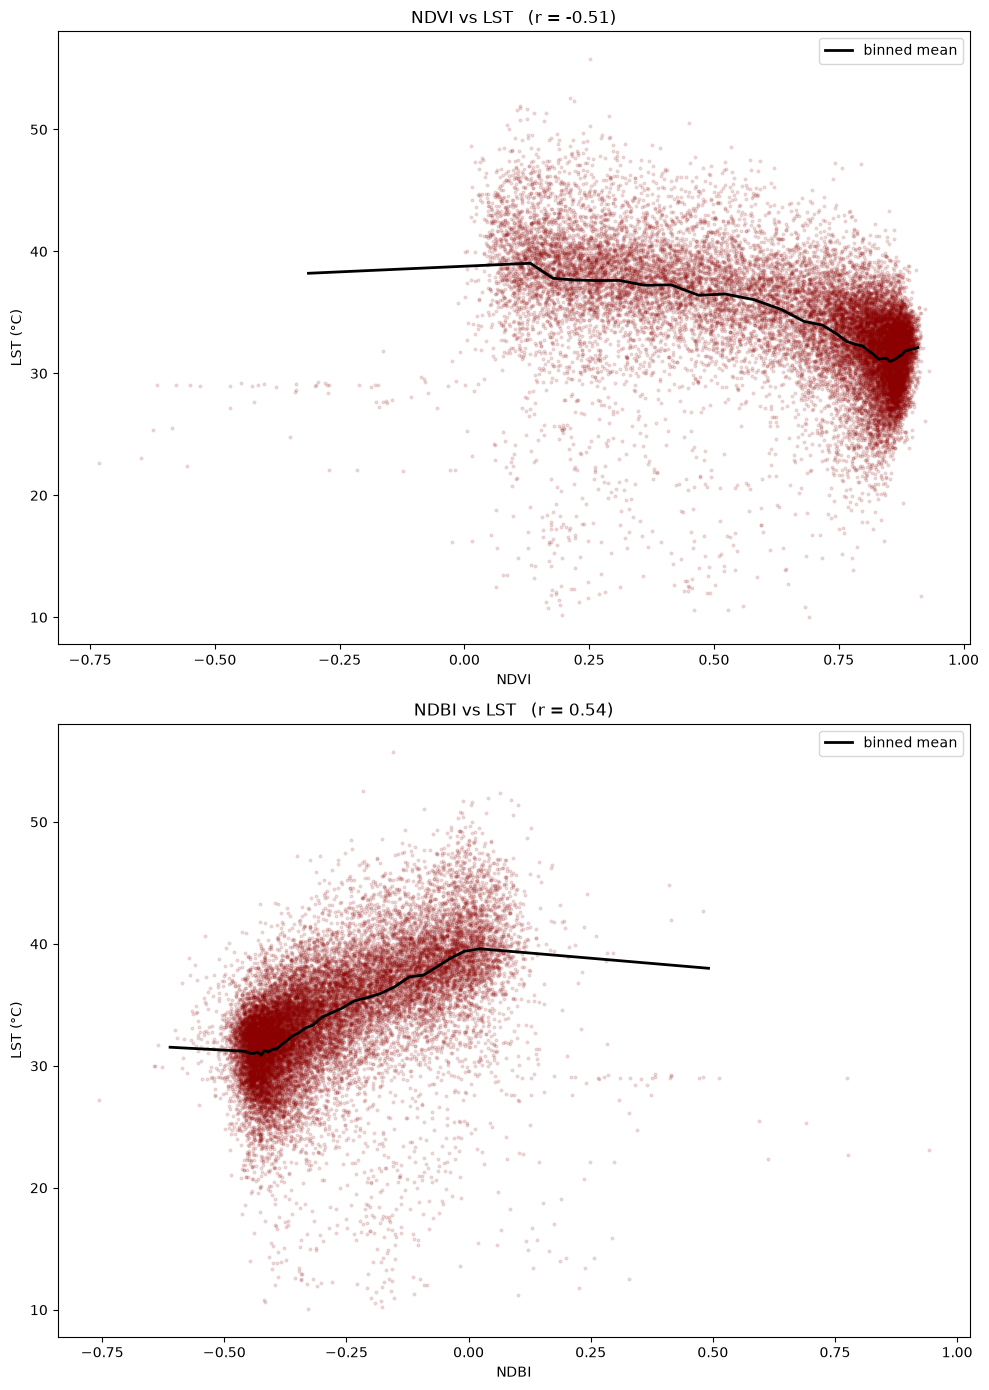

In [9]:
samp = stack.sample(min(20000, len(stack)), random_state=42)

fig, axes = plt.subplots(2, 1, figsize=(10, 14))
for ax, var, lab in zip(axes, ["ndvi", "ndbi"], ["NDVI", "NDBI"]):
    ax.scatter(samp[var], samp["lst"], s=4, alpha=0.12, color="darkred")
    # binned mean exposes non-linear structure a point cloud hides
    prof = samp.groupby(pd.qcut(samp[var], 30, duplicates="drop"), observed=True)["lst"].mean()
    ax.plot([i.mid for i in prof.index], prof.values, color="black", lw=2, label="binned mean")
    ax.set_xlabel(lab); ax.set_ylabel("LST (°C)")
    ax.set_title(f"{lab} vs LST   (r = {stack[var].corr(stack['lst']):.2f})")
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "lst_vs_indices.png", dpi=180, bbox_inches="tight")
plt.show()

> ### Finding 2 · Vegetation and surface temperature — mechanism and threshold
>
> | pair | r |
> |---|---|
> | **LST – NDVI** | **−0.510** |
> | LST – NDBI | +0.544 |
> | NDVI – NDBI | −0.907 |
>
> **The physical basis.** NDVI is defined as
>
> $$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$
>
> Exploiting the contrast between strong chlorophyll absorption in the red band and high mesophyll scattering in the near infrared. Healthy vegetation reflects little red light and a lot of NIR, pushing the index toward +1; bare soil and impervious surfaces reflect the two bands more similarly, pushing it toward 0.
>
> Surface temperature links back to how energy gets used. Plants divert a lot of the sunlight they absorb into evaporating water rather than heating up — this is why a leaf stays close to air temperature even in full sun and a road surface does not. They also shade the ground beneath them. Hard, dry surfaces don't have that option: with no moisture to evaporate, the absorbed energy goes straight into heating the surface and the material below it. That's the mechanism behind the −0.51 correlation.
>
> **But the relationship isn't linear.** LST sits flat at 38–40 °C from NDVI 0 to about 0.6, then drops to 32–34 °C by 0.9. Cooling isn't incremental — it kicks in once vegetation is dense enough to approach canopy closure and sustain real evapotranspiration. A single Pearson r flattens that threshold into a slope and overstates what sparse greening actually buys you: street planting in a dense district sits on the flat part of the curve, where the measured benefit is close to nil.
>
> **On NDBI:** it correlates with NDVI at −0.907 (~82% shared variance) — in this scene, one measurement with two signs rather than two independent lines of evidence. Including both would be textbook multicollinearity, so NDBI is dropped from later analysis.

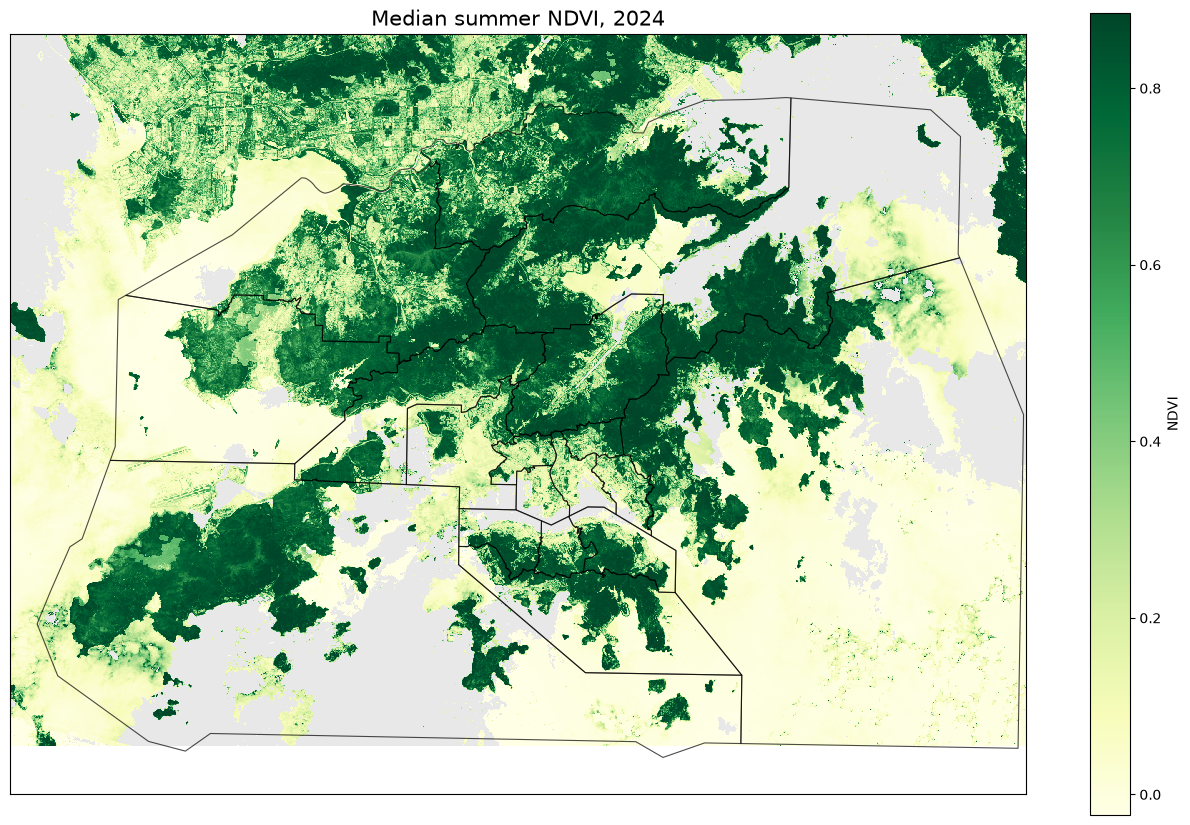

In [10]:
cmap_ndvi = plt.get_cmap("YlGn").copy(); cmap_ndvi.set_bad("#e8e8e8")
vmin, vmax = np.nanpercentile(ndvi.values, [2, 98])

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(ndvi.values, cmap=cmap_ndvi, vmin=vmin, vmax=vmax,
               extent=extent, origin="upper", interpolation="nearest")
bounds.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, alpha=0.7)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Median summer NDVI, 2024", fontsize=15)
plt.colorbar(im, ax=ax, shrink=0.75, label="NDVI")
plt.tight_layout(); plt.savefig(FIGURES / "hk_ndvi_2024.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
# Split the territory by vegetation cover. The gap between thresholds is
# deliberate — it excludes the ambiguous middle (sparse grass, mixed pixels).
built = stack[stack.ndvi < 0.4]
green = stack[stack.ndvi > 0.6]

print(f"built-up  (NDVI<0.4)  n={len(built):,}  mean LST={built.lst.mean():.1f} °C  "
      f"r(NDVI,LST)={built.ndvi.corr(built.lst):+.3f}")
print(f"vegetated (NDVI>0.6)  n={len(green):,}  mean LST={green.lst.mean():.1f} °C  "
      f"r(NDVI,LST)={green.ndvi.corr(green.lst):+.3f}")
print("\ndifference in means:", f"{built.lst.mean() - green.lst.mean():.1f}", "°C")
print("territory-wide r(NDVI, LST) for comparison:", f"{stack.ndvi.corr(stack.lst):+.3f}")

built-up  (NDVI<0.4)  n=437,151  mean LST=37.8 °C  r(NDVI,LST)=+0.022
vegetated (NDVI>0.6)  n=1,124,713  mean LST=32.2 °C  r(NDVI,LST)=-0.319

difference in means: 5.6 °C
territory-wide r(NDVI, LST) for comparison: -0.510


> ### Finding 3 · A real 5.6 °C gap, produced by a relationship that vanishes
>
> | | n | mean LST | r(NDVI, LST) |
> |---|---|---|---|
> | Built-up (NDVI<0.4) | 437,151 | **37.8 °C** | +0.022 |
> | Vegetated (NDVI>0.6) | 1,124,713 | **32.2 °C** | −0.319 |
> | Territory-wide | 1,772,806 | — | −0.510 |
>
> **The difference between built and vegetated land is 5.6 °C.** That result is
> real, it's large, and it fits the energy balance described above.
>
> But the relationship that appears to produce it largely disappears inside the groups.
> Within built-up pixels the NDVI–LST correlation is **+0.022** — essentially zero,
> when it was −0.510 across the same territory a moment earlier — and within
> vegetated land it weakens to −0.319.
>
> This is **Simpson's paradox**: a relationship that shows up across a pooled
> population but disappears, or flips, once you look inside the subgroups. The
> territory-wide number describes a **between-group** contrast — city against
> vegetated hillside. It tends to get read as a **within-group** one, meaning that
> adding greenery to a given place makes that place cooler. These are different questions with different answers: the data supports the
> first, but inside the built-up area it gives no support to the second — and the
> second is the one that matters at the scale planning decisions are actually made.
>
> **An important qualification.** Both subsets are defined using NDVI, which limits
> how much NDVI varies within each one. Restricting the range of a variable weakens
> its correlation with anything else, regardless of whether a real relationship
> exists. So the near-zero coefficient here is partly just a result of how the
> subset was chosen — but that's actually the point worth making: you can't learn
> much about NDVI from a sample that was selected based on NDVI. Understanding
> variation within the built-up area needs a different variable. Parts 4 and 6
> provide two.


In [12]:
# How much variation is there INSIDE the built-up area? The urban/rural contrast
# is well studied; the spread within the city is what the rest of Part 6 tries
# to explain.
bu_px = stack[stack.ndvi < 0.4].lst
gr_px = stack[stack.ndvi > 0.6].lst

q = [5, 25, 50, 75, 95]
print("LST distribution (°C)")
print(f"  built-up  (n={len(bu_px):>9,})  p5/p25/p50/p75/p95:",
      np.percentile(bu_px, q).round(1))
print(f"  vegetated (n={len(gr_px):>9,})  p5/p25/p50/p75/p95:",
      np.percentile(gr_px, q).round(1))

within = np.percentile(bu_px, 95) - np.percentile(bu_px, 5)
between = bu_px.mean() - gr_px.mean()
print("\n  within built-up, p5-p95 spread :", f"{within:.1f}", "°C")
print("  built-up minus vegetated means  :", f"{between:.1f}", "°C")
print(f"  ratio                           : {within / between:.1f}x")

LST distribution (°C)
  built-up  (n=  437,151)  p5/p25/p50/p75/p95: [27.9 36.  38.4 40.7 45.4]
  vegetated (n=1,124,713)  p5/p25/p50/p75/p95: [26.1 30.1 32.4 34.4 37.9]

  within built-up, p5-p95 spread : 17.5 °C
  built-up minus vegetated means  : 5.6 °C
  ratio                           : 3.1x


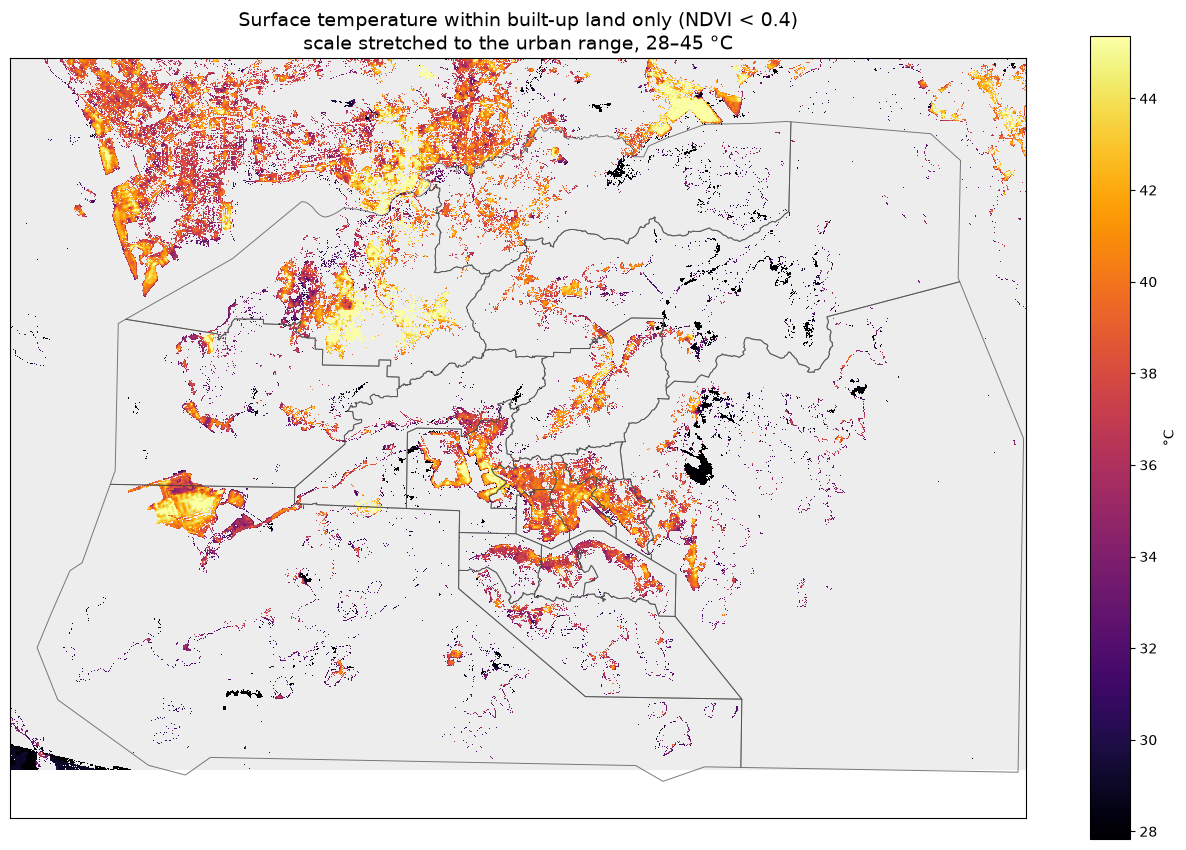

In [13]:
# LST over the urban mask only, colour scale stretched to the urban range.
# On a territory-wide scale the city reads as uniformly hot; it is not.
urban_lst = lst.where(ndvi < 0.4)
lo, hi = np.nanpercentile(urban_lst.values, [5, 95])

cmap_u = plt.get_cmap("inferno").copy(); cmap_u.set_bad("#ededed")

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(urban_lst.values, cmap=cmap_u, vmin=lo, vmax=hi,
               extent=extent, origin="upper", interpolation="nearest")
bounds.boundary.plot(ax=ax, edgecolor="#444444", linewidth=0.7, alpha=0.7)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title(f"Surface temperature within built-up land only (NDVI < 0.4)\n"
             f"scale stretched to the urban range, {lo:.0f}–{hi:.0f} °C", fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.75, label="°C")

plt.tight_layout(); plt.savefig(FIGURES / "hk_lst_urban_only.png", dpi=200, bbox_inches="tight")
plt.show()

> ### The variation this part sets out to explain
>
> The urban–rural contrast is the well-studied part of urban heat, and Finding 3
> put it at **5.6 °C**. The spread *inside* the built-up area is bigger than that.
>
> | | p5 | p25 | p50 | p75 | p95 |
> |---|---|---|---|---|---|
> | Built-up (n = 437,151) | 27.9 | 36.0 | 38.4 | 40.7 | 45.4 |
> | Vegetated (n = 1,124,713) | 26.1 | 30.1 | 32.4 | 34.4 | 37.9 |
>
> **The middle 50% of built-up pixels spans 4.7 °C** (36.0 to 40.7) — nearly the
> whole 5.6 °C difference between built-up and vegetated land. The wider p5–p95
> range gives **17.5 °C**, over three times the urban–rural contrast, though that
> figure includes tails that probably contain mixed pixels near vegetation or water
> and any cloud edge that survived masking. The interquartile range is the safer
> number and it's enough for the argument.
>
> Either way, two places both classed as urban, both with NDVI below 0.4, routinely
> differ by more than the gap between the city and the country parks.
>
> The map shows this. On a territory-wide colour scale the urban core looks
> uniformly hot, because the scale has to stretch far enough to include
> mountaintops. Rescale it to the urban range alone and a lot of internal structure
> appears.
>
> **This is the variation that matters for planning.** Nothing turns a district into
> a hillside, so the 5.6 °C contrast isn't something you can act on. The difference
> between one hot street and a cooler one a kilometre away is. It's also the
> variation that Findings 3 and 5 showed vegetation and elevation can't account for
> — which is what the rest of Part 6 looks into, and what Finding 9 concludes on.


In [14]:
# Does the NDVI-LST correlation depend on the scale it is measured at?
src = xr.Dataset({"lst": lst, "ndvi": ndvi})
rows = []

for f in [1, 2, 4, 8, 16, 32]:
    if f == 1:
        d = pd.DataFrame({"lst": lst.values.ravel(),
                          "ndvi": ndvi.values.ravel()}).dropna()
    else:
        d = (src.coarsen(x=f, y=f, boundary="trim").mean()
             .to_dataframe().reset_index()[["lst", "ndvi"]].dropna())
    rows.append({"cell_m": f * 30, "n": len(d), "r": round(d.ndvi.corr(d.lst), 3)})

print(pd.DataFrame(rows).to_string(index=False))

 cell_m       n      r
     30 1773058 -0.507
     60  454823 -0.468
    120  118611 -0.407
    240   31760 -0.316
    480    8835 -0.210
    960    2554 -0.126


In [15]:
# District means, computed by rasterising district IDs onto the existing grid.
# No GeoTIFF round-trip, so alignment between the two variables is guaranteed.
tr = Affine(RESOLUTION, 0.0, float(lst.x.min()) - RESOLUTION / 2,
            0.0, -RESOLUTION, float(lst.y.max()) + RESOLUTION / 2)
did = rasterize([(g, i + 1) for i, g in enumerate(bounds.geometry)],
                out_shape=lst.shape, transform=tr, fill=0, dtype="int32")

tmp = pd.DataFrame({"d": did.ravel(), "lst": lst.values.ravel(),
                    "ndvi": ndvi.values.ravel()}).dropna()
tmp = tmp[tmp.d > 0]

agg = tmp.groupby("d").agg(lst=("lst", "mean"), ndvi=("ndvi", "mean"), n=("lst", "size"))
agg.insert(0, "district", bounds.iloc[agg.index - 1][name_col].values)
agg = agg.sort_values("lst", ascending=False)

print(agg.round(2).to_string(index=False))
print("\nr(district NDVI, district LST) =", f"{agg.ndvi.corr(agg.lst):+.3f}",
      f"  (n={len(agg)})")

         district       lst  ndvi      n
     Kowloon City 39.119999  0.28  11544
    Yau Tsim Mong 38.630001  0.23   8431
        Kwun Tong 37.950001  0.38  12969
     Sham Shui Po 37.880001  0.39  10718
        Yuen Long 36.799999  0.59 156979
       Kwai Tsing 36.240002  0.43  28073
         Wan Chai 34.439999  0.57  11952
     Wong Tai Sin 34.130001  0.60  10215
          Eastern 33.709999  0.62  20568
         Sai Kung 33.459999  0.71 159280
Central & Western 33.389999  0.59  14187
         Tuen Mun 33.169998  0.60  77604
            North 33.169998  0.72 159724
         Southern 33.130001  0.70  46155
          Sha Tin 32.610001  0.71  76673
           Tai Po 32.139999  0.76 164665
          Islands 31.120001  0.68 203368
        Tsuen Wan 30.740000  0.72  70260

r(district NDVI, district LST) = -0.916   (n=18)


In [16]:
# Zonation: same cell size, grid origin shifted at random. Identical data,
# different boundaries — the spread is the error bar on any single reported r.
FACTOR = 16
rng = np.random.default_rng(0)
zr = []

for _ in range(100):
    ox, oy = rng.integers(0, FACTOR, 2)
    d = (src.isel(x=slice(int(ox), None), y=slice(int(oy), None))
         .coarsen(x=FACTOR, y=FACTOR, boundary="trim").mean()
         .to_dataframe().reset_index()[["lst", "ndvi"]].dropna())
    zr.append(d.ndvi.corr(d.lst))

zr = np.array(zr)
print("480 m cells, 100 random grid origins")
print("  r range ", f"{zr.min():+.3f}", "to", f"{zr.max():+.3f}",
      f"  (spread {zr.max() - zr.min():.3f})")
print("  mean    ", f"{zr.mean():+.3f}", "  sd", f"{zr.std():.3f}")

480 m cells, 100 random grid origins
  r range  -0.219 to -0.201   (spread 0.018)
  mean     -0.212   sd 0.004


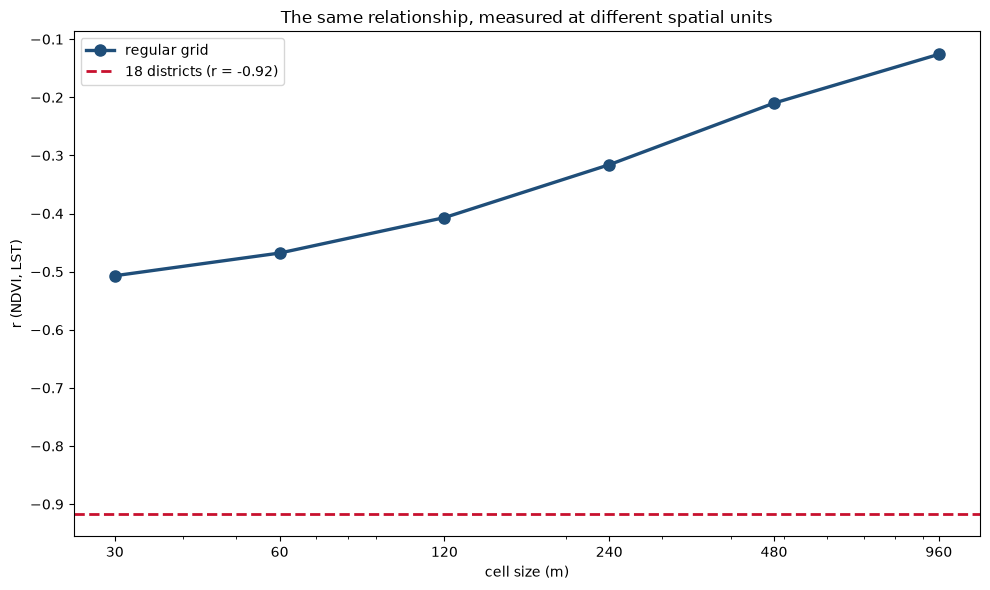

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sw = pd.DataFrame(rows)
ax.plot(sw.cell_m, sw.r, marker="o", ms=8, lw=2.4, color="#1f4e79", label="regular grid")
ax.axhline(agg.ndvi.corr(agg.lst), color="#c8102e", lw=2, ls="--",
           label=f"18 districts (r = {agg.ndvi.corr(agg.lst):+.2f})")
ax.set_xscale("log")
ax.set_xticks(sw.cell_m); ax.set_xticklabels(sw.cell_m)
ax.set_xlabel("cell size (m)"); ax.set_ylabel("r (NDVI, LST)")
ax.set_title("The same relationship, measured at different spatial units")
ax.legend()
plt.tight_layout(); plt.savefig(FIGURES / "maup_scale_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

> ### Finding 4 · The same relationship, reported as anything from −0.13 to −0.92
>
> | spatial unit | n | r (NDVI, LST) |
> |---|---|---|
> | 30 m pixels | 1,773,058 | **−0.507** |
> | 60 m cells | 454,823 | −0.468 |
> | 120 m cells | 118,611 | −0.407 |
> | 240 m cells | 31,760 | −0.316 |
> | 480 m cells | 8,835 | −0.210 |
> | 960 m cells | 2,554 | **−0.126** |
> | **18 administrative districts** | 18 | **−0.916** |
>
> Finding 1 said that results depend on the units you choose. This measures how
> much. Same data, same territory, same season — and the reported correlation
> between vegetation and surface temperature runs from **−0.13 to −0.916**, from
> negligible to almost deterministic, purely because of the spatial units it was
> calculated on.
>
> The table contains both halves of the Modifiable Areal Unit Problem, and they
> behave differently.
>
> **The scale effect** is the steady decline down the regular-grid rows. That runs
> against the usual expectation, since aggregating normally raises correlations by
> averaging out noise (Robinson, 1950). Here it does the opposite, and Finding 2
> explains why: the NDVI–LST relationship is a **threshold response**, flat until
> roughly NDVI 0.6. Aggregating creates mixed cells whose values get pulled toward
> the middle of the NDVI range — exactly the flat part, where surface temperature
> doesn't respond. So coarsening the grid moves observations into the region where
> the relationship is weakest.
>
> **The zonation effect** is the district row, which sits well off that trend.
> Districts are larger in area than 960 m cells and still return a correlation seven
> times stronger, because they aren't arbitrary tiles. Hong Kong's district
> boundaries happen to separate the dense Kowloon peninsula from the country parks
> of the New Territories, so aggregating to them groups like with like and maximises
> the variance between units. This is the ecological fallacy in classic form: a
> district-level study would conclude that vegetation almost entirely determines
> surface temperature, and a 960 m gridded study that it barely matters.
>
> **Grid offset, on the other hand, makes almost no difference.** Shifting the origin
> of a 480 m grid across 100 random positions moves r only between −0.219 and
> −0.201, a spread of 0.018. So the precise claim is that **the shape and
> meaningfulness of the units matter enormously, while their offset doesn't** — which
> is more useful than the general warning MAUP usually gets.


---
# Part 4 · Elevation

Copernicus GLO-30. This is a different product on a different native grid, so
alignment to the Landsat grid is imposed explicitly rather than assumed.


In [18]:
dem_items = catalog.search(collections=["cop-dem-glo-30"], bbox=HK_BBOX).item_collection()
dem_ds = odc.stac.load(dem_items, bands=["data"], crs=CRS,
                       resolution=RESOLUTION, bbox=HK_BBOX, chunks={})

elev = dem_ds.data.squeeze()
if "time" in elev.dims:
    elev = elev.max(dim="time")
elev = elev.where((elev > -10) & (elev < 1200)).compute()
elev = elev.interp(x=lst.x, y=lst.y, method="nearest")   # impose the LST grid

print("elevation p5/p50/p95:", np.nanpercentile(elev.values, [5, 50, 95]).round(0),
      " max:", round(float(np.nanmax(elev.values))))

elevation p5/p50/p95: [  0.   0. 272.]  max: 955


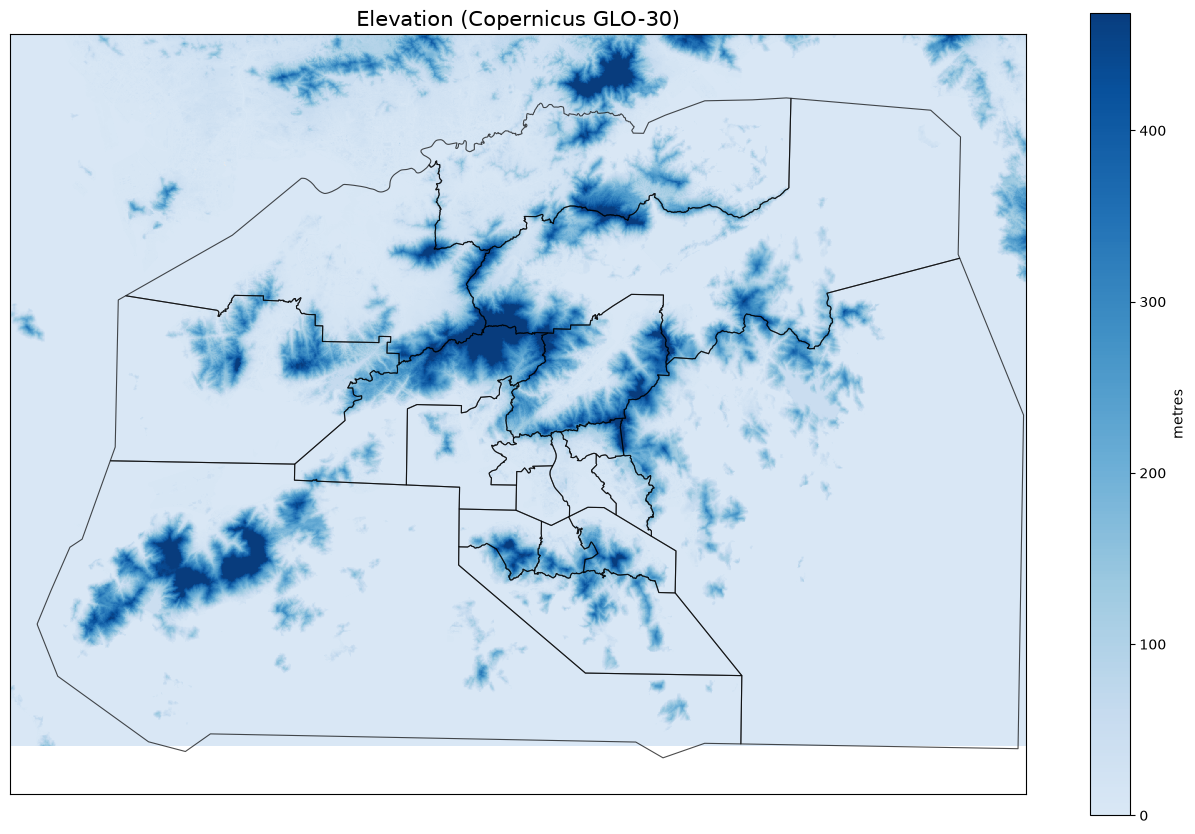

In [19]:
cmap_elev = mcolors.LinearSegmentedColormap.from_list(
    "babyblue", plt.get_cmap("Blues")(np.linspace(0.15, 0.95, 256)))
cmap_elev.set_bad("#e8e8e8")

vmin, vmax = np.nanpercentile(elev.values, [1, 99])

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(elev.values, cmap=cmap_elev, vmin=vmin, vmax=vmax,
               extent=extent, origin="upper", interpolation="nearest")
bounds.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, alpha=0.7)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Elevation (Copernicus GLO-30)", fontsize=15)
plt.colorbar(im, ax=ax, shrink=0.75, label="metres")
plt.tight_layout(); plt.savefig(FIGURES / "hk_elevation.png", dpi=200, bbox_inches="tight")
plt.show()

In [20]:
stack2 = pd.DataFrame({"lst": lst.values.ravel(),
                       "ndvi": ndvi.values.ravel(),
                       "elev": elev.values.ravel()}).dropna()

slope, _ = np.polyfit(stack2.elev, stack2.lst, 1)
observed, ATMOSPHERIC = slope * 100, -0.65
bu = stack2[stack2.ndvi < 0.4]

print("ELEVATION AND SURFACE TEMPERATURE")
print("=" * 52)
print(f"\nTerritory-wide  (n = {len(stack2):,})")
print("  r(LST, elevation)     ", f"{stack2.elev.corr(stack2.lst):+.3f}")
print("  observed lapse rate   ", f"{observed:+.2f}", "°C / 100 m")
print("  atmospheric standard  ", f"{ATMOSPHERIC:+.2f}", "°C / 100 m")
print(f"  ratio                   {observed / ATMOSPHERIC:.1f}x too steep")

print("\nWhy — elevation is not acting alone")
print("  r(NDVI, elevation)    ", f"{stack2.elev.corr(stack2.ndvi):+.3f}")

print(f"\nWithin built-up only  (NDVI < 0.4, n = {len(bu):,})")
print("  r(LST, elevation)     ", f"{bu.elev.corr(bu.lst):+.3f}")
print("\n" + "=" * 52)

ELEVATION AND SURFACE TEMPERATURE

Territory-wide  (n = 1,773,042)
  r(LST, elevation)      -0.546
  observed lapse rate    -2.10 °C / 100 m
  atmospheric standard   -0.65 °C / 100 m
  ratio                   3.2x too steep

Why — elevation is not acting alone
  r(NDVI, elevation)     +0.484

Within built-up only  (NDVI < 0.4, n = 437,388)
  r(LST, elevation)      -0.006



> ### Finding 5 · An elevation gradient too steep to be atmospheric
>
> | | value |
> |---|---|
> | r(LST, elevation), territory-wide | −0.546 |
> | Implied lapse rate | **−2.10 °C / 100 m** |
> | Environmental lapse rate (standard) | −0.65 °C / 100 m |
> | r(LST, elevation), within built-up | **−0.006** |
> | r(NDVI, elevation) | +0.484 |
>
> Surface temperature falls with altitude at roughly **three times** the standard
> environmental lapse rate. Altitude on its own can't produce a gradient that steep:
> the atmosphere cools with height at a rate set by adiabatic processes, and
> −2.10 °C/100 m is well outside it.
>
> Two things point to what else is going on. NDVI and elevation correlate at
> **+0.484** — in Hong Kong, high ground is forested, undeveloped and a long way from
> the urban core, so elevation is tangled up with land cover across the territory.
> And the correlation **collapses to −0.006 within built-up pixels**. That needs
> care: built-up land sits almost entirely near sea level, and a variable with that
> little range would show a weak correlation regardless (range restriction, which
> Finding 10 returns to). The collapse is consistent with elevation mattering little
> once land cover is held roughly constant, but on its own it doesn't prove it.
>
> Both are consistent with elevation standing in for land cover rather than acting
> as an independent control on surface temperature. But this is still an inference
> from satellite data alone, tested against a textbook constant rather than against
> a measurement. **Part 6 comes back to it with thermometers** and settles the
> question directly.


---
# Part 5 · Ground truth: air temperature

Everything so far measures the radiating surface. Heat exposure tracks **air
temperature**, and no satellite measures that at a useful resolution — ERA5 and
ERA5-Land give 2 m air temperature at 31 km and 9 km, which for a territory 50 km
across works out to roughly four and thirty grid cells. Reanalysis can't resolve
variation inside a city at all.

So air temperature comes in here as **validation, not as the subject**. The Hong
Kong Observatory publishes daily records through an open API, and 38 stations have
`CLMTEMP` (daily mean) coverage for 2024.

The trade is a stark one: about 1.7 million pixels of the wrong variable against 38
points of the right one. Neither is enough on its own, and that tension is the
project.


In [21]:
# 38 CLMTEMP stations with 2024 coverage. Coordinates from the HKO station
_STATIONS = [
    ("CCH", "Cheung Chau",              "22 12 04", "114 01 36",  72),
    ("CWB", "Clear Water Bay",          "22 15 48", "114 17 59",  66),
    ("HKA", "HK International Airport", "22 18 34", "113 55 19",   6),
    ("HKO", "Hong Kong Observatory",    "22 18 07", "114 10 27",  32),
    ("HKP", "Hong Kong Park",           "22 16 42", "114 09 44",  26),
    ("HKS", "Wong Chuk Hang",           "22 14 52", "114 10 25",   5),
    ("HPV", "Happy Valley",             "22 16 14", "114 11 01",   5),
    ("JKB", "Tseung Kwan O",            "22 18 57", "114 15 20",  38),
    ("KLT", "Kowloon City",             "22 20 06", "114 11 05",  92),
    ("KP",  "King's Park",              "22 18 43", "114 10 22",  65),
    ("KSC", "Kau Sai Chau",             "22 22 13", "114 18 45",  39),
    ("KTG", "Kwun Tong",                "22 19 07", "114 13 29",  90),
    ("LFS", "Lau Fau Shan",             "22 28 08", "113 59 01",  31),
    ("NGP", "Ngong Ping",               "22 15 31", "113 54 46", 593),
    ("PEN", "Peng Chau",                "22 17 28", "114 02 36",  34),
    ("PLC", "Tai Mei Tuk",              "22 28 31", "114 14 15",  51),
    ("SE1", "Kai Tak Runway Park",      "22 18 18", "114 13 01",   4),
    ("SEK", "Shek Kong",                "22 26 10", "114 05 05",  16),
    ("SHA", "Sha Tin",                  "22 24 09", "114 12 36",   6),
    ("SKG", "Sai Kung",                 "22 22 32", "114 16 28",   4),
    ("SKW", "Shau Kei Wan",             "22 16 54", "114 14 10",  53),
    ("SSH", "Sheung Shui",              "22 30 07", "114 06 40",  10),
    ("SSP", "Sham Shui Po",             "22 20 09", "114 08 13",  11),
    ("STY", "Stanley",                  "22 12 51", "114 13 07",  31),
    ("TC",  "Tate's Cairn",             "22 21 28", "114 13 04", 572),
    ("TKL", "Ta Kwu Ling",              "22 31 43", "114 09 24",  15),
    ("TMS", "Tai Mo Shan",              "22 24 38", "114 07 28", 955),
    ("TU1", "Tuen Mun Children's Home", "22 23 09", "113 57 51",  28),
    ("TW",  "Tsuen Wan Shing Mun Vly",  "22 22 32", "114 07 36",  35),
    ("TWN", "Tsuen Wan",                "22 23 01", "114 06 28", 142),
    ("TY1", "New Tsing Yi Station",     "22 20 39", "114 06 36",   8),
    ("TYW", "Pak Tam Chung",            "22 24 10", "114 19 23",   5),
    ("VP1", "The Peak",                 "22 15 51", "114 09 18", 406),
    ("WGL", "Waglan Island",            "22 10 56", "114 18 12",  56),
    ("WLP", "Wetland Park",             "22 28 00", "114 00 32",   4),
    ("WTS", "Wong Tai Sin",             "22 20 22", "114 12 19",  21),
    ("YCT", "Tai Po (Yuen Chau Tsai)",  "22 26 54", "114 10 38",   6),
    ("YLP", "Yuen Long Park",           "22 26 27", "114 01 06",   8)]

def _dms(s):
    d, mi, sec = (float(v) for v in s.split())
    return d + mi / 60 + sec / 3600

stations = pd.DataFrame(_STATIONS, columns=["code", "name", "_lat", "_lon", "elev_m"])
stations["lat"] = stations._lat.map(_dms)
stations["lon"] = stations._lon.map(_dms)
stations = stations.drop(columns=["_lat", "_lon"])

print(len(stations),
      f"stations, elevation {stations.elev_m.min()}–{stations.elev_m.max()} m")

38 stations, elevation 4–955 m


In [22]:
HKO_URL = "https://data.weather.gov.hk/weatherAPI/opendata/opendata.php"

def fetch_clm(station, datatype="CLMTEMP", year=2024):
    """Daily climate record for one station. CLMTEMP = mean, CLMMAXT = max."""
    r = requests.get(HKO_URL, params={"dataType": datatype, "station": station,
                                      "year": year, "rformat": "csv"}, timeout=30)
    r.raise_for_status()
    lines = r.text.splitlines()
    start = next(i for i, l in enumerate(lines) if "Year" in l)   # skip title lines
    df = pd.read_csv(io.StringIO("\n".join(lines[start:])), on_bad_lines="skip")

    df = df.iloc[:, :5]
    df.columns = ["year", "month", "day", "value", "completeness"][:df.shape[1]]
    for c in ["year", "month", "day", "value"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["year", "month", "day", "value"])

    df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=df.day))
    df["code"] = station
    return df[["code", "date", "value", "completeness"]]

print(fetch_clm("KP").head())

  code       date  value completeness
0   KP 2024-01-01   19.4            C
1   KP 2024-01-02   18.0            C
2   KP 2024-01-03   18.3            C
3   KP 2024-01-04   16.4            C
4   KP 2024-01-05   18.5            C


In [23]:
# Slow cell — 76 API calls with a courtesy delay
frames = []
for dt in ["CLMTEMP", "CLMMAXT"]:
    for code in stations.code:
        try:
            d = fetch_clm(code, datatype=dt); d["stat"] = dt; frames.append(d)
        except Exception as e:
            print(" ", dt, f"{code}:", e)
        time.sleep(0.3)

air = pd.concat(frames, ignore_index=True)
air = air.pivot_table(index=["code", "date"], columns="stat", values="value").reset_index()
air.columns.name = None
air = air.rename(columns={"CLMTEMP": "air_mean", "CLMMAXT": "air_max"})

print(f"{len(air):,}", "station-days,", air.code.nunique(), "stations")
air.to_csv(RESULTS / "hko_air_temp_2024.csv", index=False)

13,784 station-days, 38 stations


In [24]:
tf = Transformer.from_crs("EPSG:4326", CRS, always_xy=True)
sx, sy = tf.transform(stations.lon.values, stations.lat.values)

xs = xr.DataArray(sx, dims="station", coords={"station": stations.code.values})

ys = xr.DataArray(sy, dims="station", coords={"station": stations.code.values})

# Per-date LST at station pixels — uses lst_c (the pre-median stack), not the composite
lst_pts = lst_c.sel(x=xs, y=ys, method="nearest").compute()

lst_df = (lst_pts.to_dataframe(name="lst").reset_index()[["station", "time", "lst"]]
          .rename(columns={"station": "code"}).dropna(subset=["lst"]))
lst_df["date"] = pd.to_datetime(lst_df.time).dt.normalize()

# Land cover around each station, for the siting test
stations["ndvi_point"] = ndvi.sel(x=xs, y=ys, method="nearest").compute().values
R = 500
stations["ndvi_500m"] = [
    float(ndvi.sel(x=slice(x - R, x + R), y=slice(y + R, y - R)).mean(skipna=True))
    for x, y in zip(sx, sy)]

print(len(lst_df), "valid station-date LST observations")

216 valid station-date LST observations


In [25]:
m = lst_df.merge(air, on=["code", "date"], how="inner").merge(
    stations[["code", "name", "elev_m", "ndvi_point", "ndvi_500m"]], on="code")

# Cloud filter. Cloud tops are extremely cold in the thermal band, so undetected
# cloud reads as impossibly low LST. The median composite absorbed these; the
# per-date values at station points carry them directly.
before = len(m)
m = m[(m.lst > 20) & (m.lst < 60)].copy()
print("cloud filter dropped", before - len(m), "of", before,
      f"({100 * (before - len(m)) / before:.0f}%)")
print("n =", len(m), "matched station-dates,", m.code.nunique(), "stations")

cloud filter dropped 28 of 212 (13%)
n = 184 matched station-dates, 37 stations


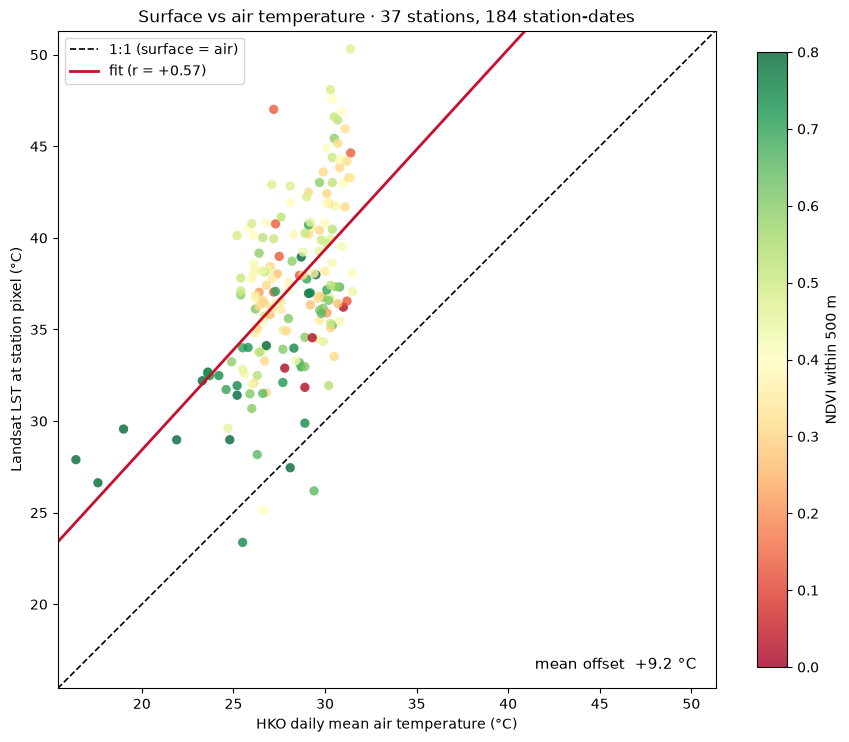

In [26]:
p = m.dropna(subset=["air_mean", "lst", "ndvi_500m"])

fig, ax = plt.subplots(figsize=(9, 8.5))
sc = ax.scatter(p.air_mean, p.lst, c=p.ndvi_500m, cmap="RdYlGn",
                s=45, alpha=0.8, edgecolor="none", vmin=0, vmax=0.8)

lims = [min(p.air_mean.min(), p.lst.min()) - 1, max(p.air_mean.max(), p.lst.max()) + 1]
ax.plot(lims, lims, "k--", lw=1.2, label="1:1 (surface = air)")

b, a = np.polyfit(p.air_mean, p.lst, 1)
ax.plot(np.linspace(*lims, 50), b * np.linspace(*lims, 50) + a,
        color="#c8102e", lw=2, label=f"fit (r = {p.lst.corr(p.air_mean):+.2f})")

ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("HKO daily mean air temperature (°C)")
ax.set_ylabel("Landsat LST at station pixel (°C)")
ax.set_title(f"Surface vs air temperature · {p.code.nunique()} stations, {len(p)} station-dates")
ax.legend(loc="upper left")
plt.colorbar(sc, ax=ax, shrink=0.75, label="NDVI within 500 m")
ax.text(0.97, 0.03, f"mean offset  +{(p.lst - p.air_mean).mean():.1f} °C",
        transform=ax.transAxes, ha="right", fontsize=11)

plt.tight_layout(); plt.savefig(FIGURES / "lst_vs_airtemp.png", dpi=200, bbox_inches="tight")
plt.show()

In [27]:
print("1. LST vs AIR TEMPERATURE")
for col, lab in [("air_mean", "daily mean"), ("air_max", "daily max")]:
    d = m.dropna(subset=[col])
    print(f"   r(LST, {lab:11}) =", f"{d.lst.corr(d[col]):+.3f}", f"  (n={len(d)})")
print("   mean LST - mean air =", f"{(m.lst - m.air_mean).mean():+.1f}", "°C")

# Averaging over dates first strips the shared weather signal and asks only
# about PLACES. Spearman ignores the constant offset and compares rank order.
sm = m.groupby(["code", "name"]).agg(lst=("lst", "mean"), air=("air_mean", "mean")).reset_index()
rho, pval = spearmanr(sm.lst, sm.air)
print(f"\n2. RANK AGREEMENT ACROSS STATIONS  (n={len(sm)})")
print("   Spearman rho =", f"{rho:+.3f}", "  p =", f"{pval:.4f}")
print("   Pearson r    =", f"{sm.lst.corr(sm.air):+.3f}")

# Is the surface-air error constant, or does it vary with land cover?
m["gap"] = m.lst - m.air_mean
gaps = m.groupby("code").agg(gap=("gap", "mean"), ndvi=("ndvi_500m", "first"))
print("\n3. LST - AIR GAP vs SURROUNDINGS")
print("   r(gap, NDVI 500m) =", f"{gaps.gap.corr(gaps.ndvi):+.3f}")
print("   gap range:", f"{gaps.gap.min():+.1f}", "to", f"{gaps.gap.max():+.1f}", "°C")

# Do the stations sample the land cover that Hong Kong is actually made of?
terr = ndvi.values[np.isfinite(ndvi.values)]
print("\n4. STATION SITING")
print("   territory NDVI p25/p50/p75:", np.percentile(terr, [25, 50, 75]).round(2))
print("   station   NDVI p25/p50/p75:",
      np.percentile(stations.ndvi_500m.dropna(), [25, 50, 75]).round(2))
print("   stations below NDVI 0.4:", (stations.ndvi_500m < 0.4).sum(), "of", len(stations))
print("   stations above NDVI 0.6:", (stations.ndvi_500m > 0.6).sum(), "of", len(stations))
print("   territory share below 0.4:", f"{(terr < 0.4).mean():.1%}")

1. LST vs AIR TEMPERATURE
   r(LST, daily mean ) = +0.572   (n=184)
   r(LST, daily max  ) = +0.493   (n=184)
   mean LST - mean air = +9.2 °C

2. RANK AGREEMENT ACROSS STATIONS  (n=37)
   Spearman rho = +0.538   p = 0.0006
   Pearson r    = +0.622

3. LST - AIR GAP vs SURROUNDINGS
   r(gap, NDVI 500m) = -0.225
   gap range: +3.7 to +15.7 °C

4. STATION SITING
   territory NDVI p25/p50/p75: [0.01 0.22 0.77]
   station   NDVI p25/p50/p75: [0.33 0.43 0.6 ]
   stations below NDVI 0.4: 17 of 38
   stations above NDVI 0.6: 10 of 38
   territory share below 0.4: 58.8%


> ### Finding 6 · Surface temperature runs 9 °C above air temperature
>
> After cloud filtering, **184 station-dates across 37 stations**.
>
> | | result |
> |---|---|
> | **mean LST − air temperature** | **+9.2 °C** |
> | gap range across stations | +3.7 to +15.7 °C |
> | r(LST, daily mean air) | +0.572 |
> | r(LST, daily max air) | +0.493 |
> | Spearman rho, station rank agreement | +0.538 (p = 0.0006) |
>
> At the 10:30 overpass, Hong Kong's surfaces sit about **nine degrees above the air
> over them**. That's what the surface energy balance predicts — a dry sunlit surface
> reaches radiative equilibrium well above the surrounding air — but the size of it
> is worth stating plainly, because LST values get reported in urban heat studies as
> though they described what people are standing in.
>
> The offset also **isn't a constant**. It runs from under 4 °C to nearly 16 °C
> between stations, so you can't correct for it by subtracting a fixed number. The
> negative correlation between the gap and surrounding vegetation (r = −0.225) points
> to why: transpiring surfaces stay close to air temperature, while dry impervious
> ones depart from it a long way.
>
> **What this means for how LST gets used.** Spearman rho = 0.538 gives rho² ≈ 0.29,
> so surface temperature accounts for under a third of the variance in how air
> temperature ranks these 37 locations. Since LST is usually used comparatively — to
> work out which districts are hottest and prioritise accordingly — that's the more
> important number. It's well above chance, and well below what swapping one variable
> for the other would require.


> ### Finding 7 · The observation network cannot calibrate the satellite
>
> | NDVI within 500 m | p25 | p50 | p75 |
> |---|---|---|---|
> | **Territory** | 0.01 | 0.22 | 0.77 |
> | **Stations** | 0.33 | 0.43 | 0.60 |
>
> Hong Kong's land cover is close to **bimodal** — dense urban fabric near zero,
> closed-canopy country park near 0.8 — and the territory quartiles span almost the
> whole range of the index. The station network sits only in the middle of that
> distribution. Median station NDVI is 0.43 against a territory median of 0.22, and
> **58.8%** of the territory falls below NDVI 0.4 while only 17 of 38 stations do.
>
> **This isn't a fault in the network.** It's the WMO siting standard working as
> intended. Synoptic stations go on level, open, grassy ground with plenty of
> clearance from buildings and obstructions, precisely so that a reading taken in
> Hong Kong is comparable with one taken in London. The standard exists to
> characterise the regional air mass, and it deliberately excludes the local surface
> influences that urban climatology cares about. Four of the 38 stations also sit
> above 400 m — Tai Mo Shan (955 m), Ngong Ping (593 m), Tate's Cairn (572 m) and
> The Peak (406 m).
>
> **The methodological consequence is the real point.** Because the network doesn't
> span the territory's land-cover range, it can't be used to work out how the
> surface–air relationship changes with land cover. That's why the gap-versus-NDVI
> test in Finding 6 is underpowered: at n = 37 you'd need a correlation of about
> ±0.32 for significance, and the observed −0.225 falls short — not because the
> relationship isn't there, but because the sample doesn't have the range to resolve
> it.
>
> This is range restriction again, the same mechanism as in Finding 3. The practical
> implication is that a satellite–station calibration for Hong Kong can't be built
> from the existing network alone. It would need purpose-sited instruments in the
> dense fabric and the closed canopy that the standard network, by design, stays out
> of.


In [28]:
summer = air[(air.date >= "2024-05-01") & (air.date <= "2024-10-31")]

st_mean = (summer.groupby("code")
           .agg(air_mean=("air_mean", "mean"), n_days=("air_mean", "size"))
           .reset_index()
           .merge(stations[["code", "name", "lat", "lon", "elev_m"]], on="code"))

st_mean["x"], st_mean["y"] = tf.transform(st_mean.lon.values, st_mean.lat.values)
st_mean = st_mean.sort_values("air_mean", ascending=False)

print(st_mean[["code", "name", "air_mean", "elev_m", "n_days"]].round(1).to_string(index=False))

code                     name  air_mean  elev_m  n_days
 HKA HK International Airport      29.0       6     184
 HPV             Happy Valley      28.7       5     184
 YLP           Yuen Long Park      28.5       8     184
 SE1      Kai Tak Runway Park      28.5       4     184
 HKO    Hong Kong Observatory      28.5      32     184
 WTS             Wong Tai Sin      28.4      21     184
 SSH              Sheung Shui      28.4      10     184
 SSP             Sham Shui Po      28.3      11     184
 SHA                  Sha Tin      28.2       6     181
 HKS           Wong Chuk Hang      28.2       5     184
 SKG                 Sai Kung      28.2       4     184
 TU1 Tuen Mun Children's Home      28.2      28     184
 YCT  Tai Po (Yuen Chau Tsai)      28.0       6     184
 PEN                Peng Chau      28.0      34     184
  KP              King's Park      28.0      65     184
 TY1     New Tsing Yi Station      27.9       8     184
 KLT             Kowloon City      27.9      92 

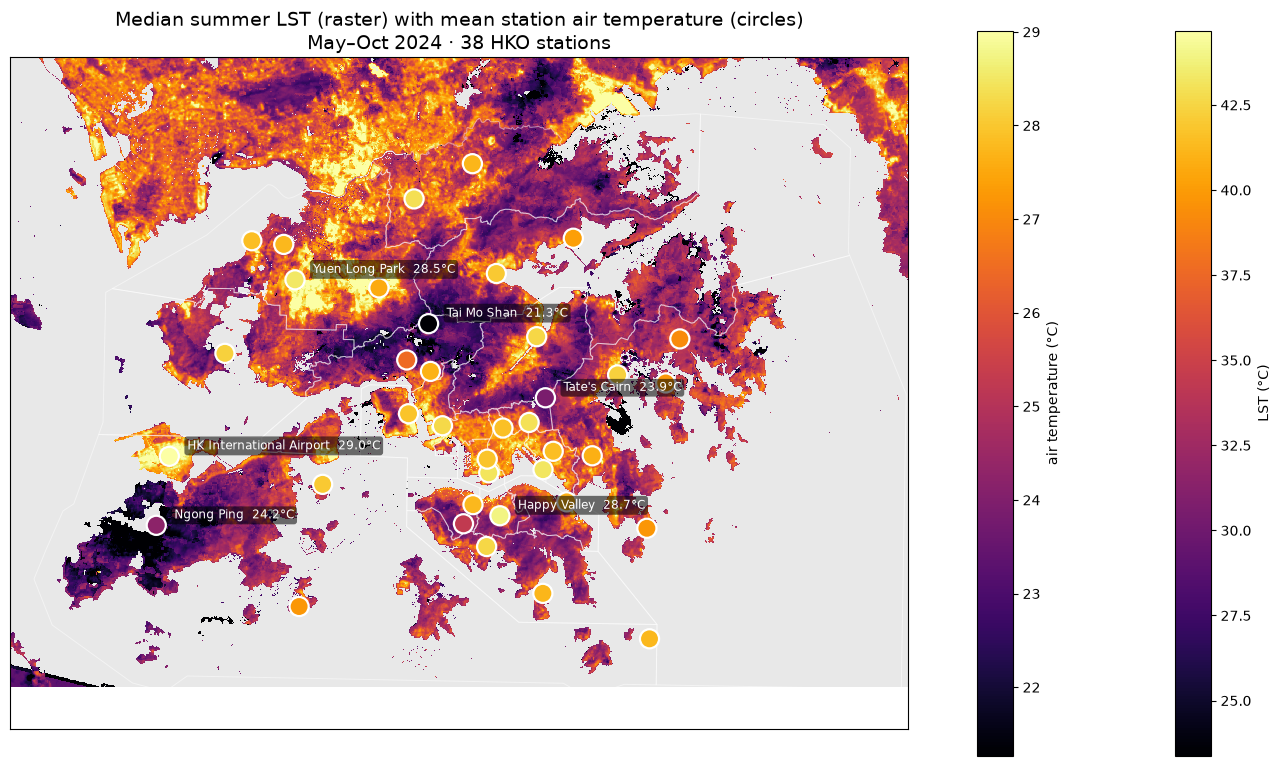

In [29]:
# LST raster with station air temperature on top. Independent colour ranges, so
# this compares spatial PATTERN rather than absolute values.
cmap = plt.get_cmap("inferno").copy(); cmap.set_bad("#e8e8e8")
lst_lo, lst_hi = np.nanpercentile(lst.values, [2, 98])

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(lst.values, cmap=cmap, vmin=lst_lo, vmax=lst_hi,
               extent=extent, origin="upper", interpolation="nearest")
bounds.boundary.plot(ax=ax, edgecolor="white", linewidth=0.7, alpha=0.5)

sc = ax.scatter(st_mean.x, st_mean.y, c=st_mean.air_mean, cmap=cmap,
                vmin=st_mean.air_mean.min(), vmax=st_mean.air_mean.max(),
                s=190, edgecolor="white", linewidth=1.6, zorder=3)

for _, r in pd.concat([st_mean.head(3), st_mean.tail(3)]).iterrows():
    ax.annotate(f"{r['name']}  {r.air_mean:.1f}°C", (r.x, r.y),
                textcoords="offset points", xytext=(13, 5), fontsize=8.5,
                color="white", zorder=4,
                bbox=dict(boxstyle="round,pad=0.25", fc="black", ec="none", alpha=0.55))

ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("Median summer LST (raster) with mean station air temperature (circles)\n"
             f"May–Oct 2024 · {len(st_mean)} HKO stations", fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.62, pad=0.02, label="LST (°C)")
plt.colorbar(sc, ax=ax, shrink=0.62, pad=0.06, label="air temperature (°C)")

plt.tight_layout(); plt.savefig(FIGURES / "lst_with_stations.png", dpi=200, bbox_inches="tight")
plt.show()

In [30]:
# Pooled correlation mixes spatial signal with shared weather — hot days are hot
# everywhere. Subtracting each date's mean across stations leaves only geography.
counts = m.groupby("date").size()
keep = counts[counts >= 5].index          # dates with 1-2 stations give 0 anomalies
md_ = m[m.date.isin(keep)].copy()
md_["lst_anom"] = md_.lst - md_.groupby("date").lst.transform("mean")
md_["air_anom"] = md_.air_mean - md_.groupby("date").air_mean.transform("mean")

print("stations per date:", counts.describe().round(1).to_dict())
print("\npooled  r =", f"{m.lst.corr(m.air_mean):+.3f}", f"  (n={len(m)})")
print("spatial r =", f"{md_.lst_anom.corr(md_.air_anom):+.3f}", f"  (n={len(md_)},",
      md_.date.nunique(), "dates)")

stations per date: {'count': 12.0, 'mean': 15.3, 'std': 9.5, 'min': 2.0, '25%': 9.0, '50%': 12.0, '75%': 20.0, 'max': 35.0}

pooled  r = +0.572   (n=184)
spatial r = +0.521   (n=182, 11 dates)


> ### Separating weather from geography
>
> | | r | n |
> |---|---|---|
> | Pooled across all station-dates | **+0.572** | 184 |
> | Date-demeaned (spatial only) | **+0.521** | 182, across 11 dates |
>
> The pooled correlation mixes two things together: whether LST tracks air
> temperature **across locations**, and whether both simply rise together on warm
> days. The second one is shared weather and would show up between any two
> thermometers in the territory. Only the first is a property of LST as a spatial
> instrument.
>
> Subtracting each date's mean across all reporting stations strips out the common
> temporal signal. **The correlation barely moves** — +0.572 to +0.521 — so the
> relationship is genuinely spatial rather than an artefact of shared weather. A
> likely reason is the study window: every scene falls in May–October, so variation
> between dates is already compressed compared with a year-round sample.
>
> This qualifies the argument rather than supporting it. LST does carry real spatial
> information about air temperature: r² ≈ 0.27, roughly a quarter of the spatial
> variance, which lines up with the Spearman rho of 0.538 found independently in
> Finding 6. So the conclusion isn't that LST tells you nothing about where a city is
> hot — it's that it accounts for a minority of that variation. Enough to guide where
> you look, not enough to replace measuring.
>
> Dates with fewer than five reporting stations are dropped, since with one or two
> stations the anomaly is zero by construction. Twelve dates had usable
> station-matched observations, and eleven passed that threshold.


---
# Part 6 · What varies inside the urban fabric

Part 3 established that NDVI can't explain variation within a subset defined by
NDVI. So this section brings in two variables that aren't:

**Surface albedo**, via the Liang (2001) narrowband-to-broadband conversion.
Physically, brighter surfaces reflect more shortwave radiation and should be
cooler.

**Distance to the coastline**, calculated from the boundary polygon. Sea breeze is
an *advective* process — it moves air around — so it gives a clean test: it should
affect air temperature more than surface temperature.

*(Building height and density are not carried into this notebook. They were joined
in an earlier exploratory version and used only to test explanations for the albedo
result in Finding 8. For the main analysis they'd recover a descriptive finding at
considerable cost, and this project is about measurement rather than taking into considerationwhat
explains heat.)*


In [31]:
# Distance to coast. EDT returns distance to the nearest zero (= sea) for each land pixel.
transform = Affine(RESOLUTION, 0.0, float(lst.x.min()) - RESOLUTION / 2,
                   0.0, -RESOLUTION, float(lst.y.max()) + RESOLUTION / 2)
land = rasterize(((g, 1) for g in bounds.geometry), out_shape=lst.shape,
                 transform=transform, fill=0, dtype="uint8")

coast = xr.DataArray((distance_transform_edt(land) * RESOLUTION) / 1000.0,
                     dims=lst.dims, coords=lst.coords).where(land == 1)

print("coast distance p5/p50/p95 (km):", np.nanpercentile(coast.values, [5, 50, 95]).round(2),
      " max:", round(float(np.nanmax(coast.values)), 2))

coast distance p5/p50/p95 (km): [ 0.69  7.43 18.69]  max: 22.14


In [32]:
ds3 = odc.stac.load(items, bands=["blue", "red", "nir08", "swir16", "swir22", "qa_pixel"],
                    crs=CRS, resolution=RESOLUTION, bbox=HK_BBOX,
                    groupby="solar_day", chunks={})

qa3 = ds3.qa_pixel
bad3 = ((qa3 & (1 << 0)) | (qa3 & (1 << 1)) | (qa3 & (1 << 2))
        | (qa3 & (1 << 3)) | (qa3 & (1 << 4))) > 0
water3 = (qa3 & (1 << 7)) > 0

def sr3(b):
    v = ds3[b].where(ds3[b] > 0) * 0.0000275 - 0.2
    return v.where(~bad3).where(~water3)

blue, red3, nir3, sw1, sw2 = (sr3(b) for b in ["blue", "red", "nir08", "swir16", "swir22"])

# Liang (2001). Coefficients derived for ETM+, applied to OLI — standard practice,
# small bias. Combined per scene before compositing, same reasoning as NDVI.
albedo = (0.356 * blue + 0.130 * red3 + 0.373 * nir3
          + 0.085 * sw1 + 0.072 * sw2 - 0.0018).median(dim="time").compute()
albedo = albedo.where((albedo > 0.02) & (albedo < 0.6))

print("albedo p5/p50/p95:", np.nanpercentile(albedo.values, [5, 50, 95]).round(3))

/opt/conda/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


albedo p5/p50/p95: [0.094 0.184 0.527]


In [33]:
allpx = pd.DataFrame({"lst": lst.values.ravel(), "ndvi": ndvi.values.ravel(),
                      "elev": elev.values.ravel(), "albedo": albedo.values.ravel(),
                      "coast_km": coast.values.ravel()}).dropna()
urban = allpx[allpx.ndvi < 0.4]

print("territory:", f"{len(allpx):,}", "px    urban (NDVI<0.4):", f"{len(urban):,}", "px\n")
print("correlation with LST:")
print(pd.DataFrame({"territory": allpx.corr()["lst"],
                    "urban only": urban.corr()["lst"]}).drop("lst").round(3).to_string())

territory: 1,242,317 px    urban (NDVI<0.4): 238,151 px

correlation with LST:
          territory  urban only
ndvi         -0.467      -0.105
elev         -0.514       0.016
albedo        0.276       0.486
coast_km     -0.001      -0.062


> ### Finding 8 · Surface albedo behaves contrary to radiative expectation
>
> | | territory | urban only (NDVI<0.4) |
> |---|---|---|
> | NDVI | −0.467 | −0.105 |
> | elevation | −0.514 | **+0.016** |
> | **albedo** | **+0.276** | **+0.486** |
> | distance to coast | −0.001 | −0.062 |
>
> Two rows here reproduce earlier results on a different subset of pixels: the NDVI
> relationship weakens as it did in Finding 3, and the elevation correlation
> collapses almost exactly as in Finding 5.
>
> **Albedo does the opposite of what radiative physics predicts.** A brighter surface
> reflects a larger share of incoming shortwave radiation, absorbs less, and should
> therefore be cooler. Here brighter surfaces are *hotter*, and the effect nearly
> doubles inside the urban mask — it gets stronger exactly where the radiative
> argument should be least contaminated by vegetation and terrain.
>
> **Five candidate explanations were tested and eliminated.** Raster misregistration
> was ruled out by checking that the LST, NDVI and albedo grids are pixel-for-pixel
> identical. Duplicate building footprints inflating density were ruled out (one
> marginal cell). Building density as a confound was tested with partial correlation,
> and the albedo effect *got stronger* once density was controlled for. Sub-pixel
> shadow mixing — the most physically plausible explanation, that cell-mean albedo is
> partly measuring shaded fraction — makes a testable prediction: within-cell albedo
> variance should rise with building height and density. The data show the opposite
> (−0.08 and −0.23), so dense cells are more spatially *uniform* in brightness, not
> less. Structural building typology was inconclusive, because the CSDI field
> available distinguishes podium from tower rather than land use.
>
> **The surviving hypothesis**, stated as a hypothesis rather than a finding: Hong
> Kong's dense high-rise fabric is genuinely and uniformly darker than its low-rise
> industrial fabric — dark curtain-wall glazing and membrane roofing against bright
> galvanised metal and light concrete — while the temperature difference between
> those two typologies is driven by canyon geometry, restricted ventilation and
> reduced sky view factor rather than by albedo itself. Two real effects sharing one
> axis of urban form, rather than one causing the other. Testing it needs a functional
> land-use classification, which the building dataset doesn't carry.
>
> **Distance to coast, by contrast, explains nothing** — −0.001 territory-wide and
> −0.062 inside the urban mask, and at station level −0.093 against air temperature
> and −0.047 against LST. The expectation was that sea breeze, being advective, would
> show up more in air temperature than in surface temperature. Neither shows a
> relationship. Reported as a null result. Hong Kong is maritime throughout — the
> median location is 7.4 km from the coast and the furthest only 22 km — so there may
> not be enough of a gradient to detect, and elevation takes up so much of the
> station-level variance that there's little left to explain.


In [34]:
# 480 m analysis grid — 16 x 16 Landsat pixels. One grid serves both the
# regression and the spatial autocorrelation test below.
FACTOR = 16
grid = (xr.Dataset({"lst": lst, "ndvi": ndvi, "elev": elev,
                    "albedo": albedo, "coast_km": coast})
        .coarsen(x=FACTOR, y=FACTOR, boundary="trim").mean()
        .to_dataframe().reset_index().dropna())

gu = grid[grid.ndvi < 0.4].copy()
print(f"{len(grid):,}", "cells at", FACTOR * RESOLUTION, "m,", f"{len(gu):,}",
      "urban (NDVI<0.4)")

6,454 cells at 480 m, 2,004 urban (NDVI<0.4)


In [35]:
import statsmodels.api as sm

# All four predictors together, standardised so coefficients are comparable
PRED = ["ndvi", "elev", "albedo", "coast_km"]
X = (gu[PRED] - gu[PRED].mean()) / gu[PRED].std()
y = (gu.lst - gu.lst.mean()) / gu.lst.std()

model = sm.OLS(y, sm.add_constant(X)).fit()
print(model.summary())

gu["resid"] = model.resid

                            OLS Regression Results                            
Dep. Variable:                    lst   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     22.16
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           6.40e-18
Time:                        10:11:26   Log-Likelihood:                -2799.6
No. Observations:                2004   AIC:                             5609.
Df Residuals:                    1999   BIC:                             5637.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.644e-07      0.022   1.21e-05      1.0

In [36]:
%pip install -q esda

Note: you may need to restart the kernel to use updated packages.


In [37]:
from libpysal.weights import KNN
from esda.moran import Moran

# k=8 approximates queen contiguity on a regular grid while guaranteeing
# every cell has neighbours; row-standardised so the lag is a neighbour mean.
w = KNN.from_array(np.c_[gu.x.values, gu.y.values], k=8)
w.transform = "r"

mi_lst = Moran(gu.lst.values, w)
mi_res = Moran(gu.resid.values, w)

print("Moran's I, LST           :", f"{mi_lst.I:+.3f}", "  p =", f"{mi_lst.p_sim:.4f}")
print("Moran's I, OLS residuals :", f"{mi_res.I:+.3f}", "  p =", f"{mi_res.p_sim:.4f}")
print("\n(I near 0 = random arrangement; 1 = perfectly clustered)")

Moran's I, LST           : +0.694   p = 0.0010
Moran's I, OLS residuals : +0.677   p = 0.0010

(I near 0 = random arrangement; 1 = perfectly clustered)


/opt/conda/lib/python3.13/site-packages/libpysal/weights/distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


> ### Finding 9 · Within the urban fabric, these variables explain almost nothing
>
> One model, fitted on 2,004 built-up cells at 480 m with all four predictors entered
> at once and standardised:
>
> | | standardised β | p |
> |---|---|---|
> | NDVI | +0.156 | <0.001 |
> | elevation | +0.091 | <0.001 |
> | albedo | +0.089 | <0.001 |
> | distance to coast | +0.049 | 0.027 |
> | | | |
> | **R²** | **0.042** | |
>
> **The model accounts for four percent of the variance in surface temperature.**
> Every variable that looked like it governed urban heat at territory scale —
> vegetation, elevation, surface brightness, maritime influence — explains
> essentially nothing once you restrict the analysis to land that is actually built
> up.
>
> This generalises Finding 3 from one variable to four. The territory-wide
> relationships were describing the contrast *between* urban and non-urban land, not
> variation *within* the urban fabric, and once that contrast is taken out there's
> very little left for these predictors to account for.
>
> Note that NDVI and elevation both take small *positive* coefficients here, where
> the bivariate pixel-level values in Finding 8 were −0.105 and +0.016. Two things
> change at the same time — the spatial unit (480 m rather than 30 m) and the move to
> multivariate control — so the sign change shouldn't be pinned on either one alone.
> Albedo likewise drops from +0.486 bivariate to +0.089 here, which is consistent
> with the aggregation-driven weakening documented in Finding 4.
>
> ### Spatial dependence
>
> | | Moran's I | p |
> |---|---|---|
> | LST | **+0.694** | 0.001 |
> | OLS residuals | **+0.677** | 0.001 |
>
> Surface temperature is strongly spatially clustered, which is expected. The
> important number is the second one: after fitting, the residuals are almost as
> clustered as the raw data. The model has removed essentially no spatial structure —
> which follows from explaining 4% — and the Durbin–Watson statistic of 0.762 says
> the same thing.
>
> **Every standard error and p-value in the table above therefore assumes an
> independence that demonstrably doesn't hold**, and is optimistic as a result. The
> coefficients are reported here descriptively rather than inferentially. This isn't a
> defect found late in the day; it's the reason the correlations throughout this
> notebook are presented as descriptive statistics, and quantifying it turns that
> caution from an assumption into a measurement.
>
> A spatial lag or spatial error specification would be the right next step, and is
> noted as such rather than attempted here.


In [38]:
xs_ = xr.DataArray(sx, dims="station", coords={"station": stations.code.values})
ys_ = xr.DataArray(sy, dims="station", coords={"station": stations.code.values})

stn = st_mean.merge(pd.DataFrame({
    "code": stations.code.values,
    "coast_km": coast.sel(x=xs_, y=ys_, method="nearest").values,
    "albedo": albedo.sel(x=xs_, y=ys_, method="nearest").values,
    "ndvi_500m": stations.ndvi_500m.values}), on="code")

stn = stn.merge(m.groupby("code").lst.mean().rename("lst_mean").reset_index(),
                on="code", how="left")

print("STATION-LEVEL COMPARISONS  (n =", len(stn.dropna(subset=["lst_mean"])), ")\n")
for var, lab in [("coast_km", "distance to coast"), ("elev_m", "elevation")]:
    d = stn.dropna(subset=[var, "air_mean", "lst_mean"])
    print(f"{lab}")
    print("   vs AIR temp : r =", f"{d[var].corr(d.air_mean):+.3f}")
    print(f"   vs LST      : r = {d[var].corr(d.lst_mean):+.3f}\n")

# The atmosphere's own lapse rate, measured with thermometers
d = stn.dropna(subset=["elev_m", "air_mean"])
slope_air, _ = np.polyfit(d.elev_m, d.air_mean, 1)
print("AIR lapse rate :", f"{slope_air * 100:+.2f}", f"°C / 100 m   (n={len(d)})")
print("LST lapse rate :", f"{observed:+.2f}", "°C / 100 m")
print("textbook       :", f"{ATMOSPHERIC:+.2f}", "°C / 100 m")

STATION-LEVEL COMPARISONS  (n = 37 )

distance to coast
   vs AIR temp : r = -0.093
   vs LST      : r = -0.047

elevation
   vs AIR temp : r = -0.958
   vs LST      : r = -0.551

AIR lapse rate : -0.72 °C / 100 m   (n=38)
LST lapse rate : -2.10 °C / 100 m
textbook       : -0.65 °C / 100 m


In [39]:
# Is the lapse rate driven by the four mountain stations? Restrict the range and see.
for cap in [1000, 200, 100]:
    sub = d[d.elev_m < cap]
    if len(sub) > 5:
        sl, _ = np.polyfit(sub.elev_m, sub.air_mean, 1)
        print("elev <", f"{cap:4}", f"m   n={len(sub):2}   lapse =", f"{sl * 100:+.2f}",
              "°C/100 m   r =", f"{sub.elev_m.corr(sub.air_mean):+.3f}")

elev < 1000 m   n=38   lapse = -0.72 °C/100 m   r = -0.963
elev <  200 m   n=34   lapse = -1.00 °C/100 m   r = -0.615
elev <  100 m   n=33   lapse = -0.81 °C/100 m   r = -0.457


> ### Finding 10 · Air temperature resolves the elevation question
>
> Finding 5 showed that LST implies an elevation gradient roughly three times the
> environmental lapse rate, and inferred that elevation must be standing in for land
> cover. That inference was tested against a textbook constant. The station data lets
> it be tested against measurements of the same territory over the same months.
>
> | | °C per 100 m |
> |---|---|
> | **Air temperature, 38 HKO stations** | **−0.72** |
> | Environmental lapse rate (standard) | −0.65 |
> | **Implied by LST** | **−2.10** |
>
> Air temperature falls with altitude at very nearly the rate atmospheric physics
> says it should, and elevation accounts for **92%** of the variance between stations
> (r = −0.958). The atmosphere over Hong Kong is behaving normally. LST, over the same
> terrain in the same season, implies a gradient three times steeper — which the
> atmosphere can't produce.
>
> **So the elevation signal in LST is land cover, not altitude**, as Finding 5
> suspected but couldn't demonstrate at the time.
>
> The result holds up whichever subset you take. Dropping the four stations above
> 400 m, and then everything above 100 m, leaves the gradient basically intact:
>
> | subset | n | lapse rate | r |
> |---|---|---|---|
> | all stations | 38 | −0.72 | −0.963 |
> | below 200 m | 34 | −1.00 | −0.615 |
> | below 100 m | 33 | −0.81 | −0.457 |
>
> Across every subset the measured atmospheric gradient sits between −0.72 and −1.00,
> against −2.10 implied by satellite. Note also that the **slope stays stable while r
> drops sharply** as the elevation range narrows — range restriction once more, and a
> reminder that the correlation coefficient and the regression slope answer different
> questions. Reporting only the correlation would have hidden a stable physical
> relationship behind a shrinking number.


---
# Part 7 · Findings and conclusions

## Summary

| # | Finding | Principal evidence |
|---|---|---|
| 1 | District aggregation reflects boundary geometry | Tsuen Wan coolest at 30.7 °C; pixel counts vary 24-fold |
| 2 | Vegetation cooling is a threshold response, not a gradient | Flat 38–40 °C to NDVI 0.6, then falling to 32–34 °C |
| 3 | The headline correlation is a between-group effect | r −0.510 territory-wide → +0.022 within built-up; 5.6 °C gap is real |
| 4 | **The same relationship spans −0.13 to −0.92 depending on units** | Scale effect across a regular grid; zonation effect at district level |
| 5 | LST implies an impossible elevation gradient | −2.10 °C/100 m; collapses to −0.006 within built-up |
| 6 | Surface runs 9.2 °C above air and ranks places differently | rho = 0.538, so rho² ≈ 0.29 |
| 7 | The station network cannot calibrate the satellite | Station NDVI 0.33–0.60 against a territory spanning 0.01–0.77 |
| 8 | Albedo behaves contrary to radiative expectation | +0.486 within urban mask; five explanations eliminated |
| 9 | **Four predictors explain 4% of urban surface temperature** | R² = 0.042; residual Moran's I = +0.677 |
| 10 | Air temperature resolves the elevation question | −0.72 °C/100 m measured, against −2.10 implied |

## Interpretation

Findings 1, 3, 4 and 9 all have the same shape. In each one, a statistic that looks
like a property of Hong Kong turns out to be a property of **how the data was divided**, ie things such as which subset, which spatial unit, which variables
were allowed to vary together. None of the findings come from a processing error, and each
would pass unnoticed in an analysis that reported relations/coefficients that are on a teritory wide scale.

Finding 4 is the clearest case. From identical data, the correlation between
vegetation and surface temperature can be reported as anything between −0.13 (practically no correlation) and
−0.916 ( a strong negative correlation). A reader given only one of those numbers has no way of telling which or why there is this difference in correlation.

It's worth restating how much goes unexplained. The middle half of built-up pixels
spans 4.7 °C, almost the whole 5.6 °C urban–rural contrast, and the 5–95 percentile range
reaches 17.5 °C. The variation in the literature reports is smaller than the variation
inside the category it reports on.

Findings 6, 7, and 10 are about the instrument, not the geography. LST runs about 9 °C above air temperature on average, with the gap ranging 4–16 °C across land cover — vegetation is a likely driver (r = −0.225, correct sign), but at n = 37 that falls short of the ~0.32 critical value a standard significance table gives for that sample size, so it can't be called significant. The two measures agree on only about a quarter to a third of the spatial pattern (r² ≈ 0.27–0.29). The network is meant to explain WMO siting keeps stations in the mid-range of vegetation cover, away from the extremes where LST and air temperature diverge the most.

Finding 8 is still unresolved after five attempts to explain it away (four eliminated, one inconclusive), and is reported as such. Hong Kong's building stock is unusually vertical compared to flatter cities like London, and that geometry matters for LST — but at a morning overpass it mostly works through shading, which makes high-rise pixels read cooler, rather than through canyons trapping heat, which is largely an air-temperature and night-time effect. Shading of the albedo signal itself was one of the tests and it failed: denser, taller cells turned out more uniform in albedo, not more patchy, the opposite of what was predicted. The surviving explanation combines materials and exposure — dark cladding on shaded high-rises versus bright, fully exposed roofs and open ground on low-rise industrial land, which are both brighter and hotter.

## What land surface temperature is genuinely good for

The conclusion isn't that LST is unsound. It's that its legitimate uses are narrower
than its actual usage.

**It's the right instrument for surfaces.** LST measures the radiating skin of the
ground — exactly the quantity that governs cool-roof and cool-pavement work,
identifying which rooftops and paved areas absorb the most radiation, and targeting
material retrofits. For that job the +9.2 °C offset isn't error, it's sign to moniter this.

**It's unmatched for coverage.** No realistic ground network produces a continuous
30 m thermal map of a whole territory, and the correlation of +0.522
confirms that what it captures is genuine and spatial. Therfore LST is irreplacible for deciding **where to
investigate** in these situations.

**It isn't sufficient on its own for human heat exposure**, for ranking districts by
health risk, as air temperature would dictate the risk of any heat related issues. Any result derived from it
should state the spatial unit it was calculated on, because Finding 4 shows that
choice can move the answer by a factor of seven.

## Application to Hong Kong practice

Hong Kong has already reached this conclusion institutionally. The **Urban Climatic
Map** that commissioned by the Planning Department in 2006 and developed at the Chinese
University of Hong Kong's Archiutecural department on the German VDI-3787 framework,
was built from 40 weather stations, thermal comfort
surveys, MM5/CALMET wind simulation and building inventory. It was deliberately **not** from **satellite surface
temperature**. It sorts the territory into eight climatope classes and five Urban
Climatic Planning Zones which feed into Outline Zoning Plan review aswell as having quantitative
guidance including keeping urban ground coverage below 50%.

The proposition mentioned things such as: 

> **Satellite LST can't substitute for an instrument like the Urban Climatic Map — it
> measures a different variable and would mislead if you swapped one for the other.
> But it updates annually and at no cost, where the UC-Map is a static product
> approaching two decades old. Its proper role is to identify where the territory has
> changed since that assessment was made, and to direct where ground-based
> reassessment should be prioritised.**

One tension is worth further work. The UC-Map reports that "30% greening can be
effective lowering urban air temperature by 1 degree", while Finding 2 finds no
measurable *surface* cooling until NDVI approaches 0.6. Those two statements are hard
to reconcile, and the most likely explanation is that they describe different
variables responding differently to the same intervention. Testing that directly —
paired surface and air measurements across a greening gradient — would be a natural
extension.

## Limitations

- **Surface temperature is not air temperature.** Central to the argument, but it also
  bounds what can be concluded here about heat exposure.
- **Single season, single year.** 2024 was warm, and year-to-year variability isn't
  characterised. The compressed seasonal range also explains why date-demeaning
  changed the correlation so little.
- **Cloud loss.** 184 of roughly 836 possible station-dates survived QA masking and
  cloud filtering (22%), across 12 usable dates. Landsat thermal analysis in a Hong
  Kong summer is materially constrained by cloud coverage in the city during this season especially.
- **Station sample.** 38 stations are enough for a lapse rate across a kilometre of
  relief, but not enough for anything that needs a land cover contrast, which is backed up on finding 7.
- **Inference, not just description.** Residual Moran's I of +0.677 means the OLS
  standard errors in Finding 9 are optimistic. Coefficients are reported
  descriptively; a spatial lag or error specification would be needed for formal
  inference.

## Data sources

- **Landsat 8/9 Collection 2 Level-2** — USGS, accessed via Microsoft Planetary Computer STAC
- **Copernicus DEM GLO-30** — ESA, accessed via Planetary Computer
- **Daily climate records** — Hong Kong Observatory Open Data API (`CLMTEMP`, `CLMMAXT`)
- **District boundaries** — Hong Kong SAR
- Liang, S. (2001). Narrowband to broadband conversions of land surface albedo I: Algorithms. *Remote Sensing of Environment*, 76(2), 213–238.
- Openshaw, S. (1984). *The Modifiable Areal Unit Problem*. CATMOG 38, Geo Books.
- Robinson, W. S. (1950). Ecological correlations and the behavior of individuals. *American Sociological Review*, 15(3), 351–357.
- Ng, E. et al. Urban Climatic Map and Standards for Wind Environment — Feasibility Study. Planning Department, HKSAR.
